#Data Pre-Processing

In [3]:
#importing the necessary libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import zscore

In [4]:
df=pd.read_csv("/content/car_sales.csv")
df

,Car_id,Date,Customer Name,Gender,Annual Income,Dealer_Name,Company,Model,Engine,Transmission,Color,Price ($),Dealer_No,Body Style,Phone,Dealer_Region
0,C_CND_000001,1/2/2022,Geraldine,Male,13500,Buddy Storbeck's Diesel Service Inc,Ford,Expedition,DoubleÂ Overhead Camshaft,Auto,Black,26000,06457-3834,SUV,8264678,Middletown
1,C_CND_000002,1/2/2022,Gia,Male,1480000,C & M Motors Inc,Dodge,Durango,DoubleÂ Overhead Camshaft,Auto,Black,19000,60504-7114,SUV,6848189,Aurora
2,C_CND_000003,1/2/2022,Gianna,Male,1035000,Capitol KIA,Cadillac,Eldorado,Overhead Camshaft,Manual,Red,31500,38701-8047,Passenger,7298798,Greenville
3,C_CND_000004,1/2/2022,Giselle,Male,13500,Chrysler of Tri-Cities,Toyota,Celica,Overhead Camshaft,Manual,Pale White,14000,99301-3882,SUV,6257557,Pasco
4,C_CND_000005,1/2/2022,Grace,Male,1465000,Chrysler Plymouth,Acura,TL,DoubleÂ Overhead Camshaft,Auto,Red,24500,53546-9427,Hatchback,7081483,Janesville
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23901,C_CND_023902,12/31/2023,Martin,Male,13500,C & M Motors Inc,Plymouth,Voyager,Overhead Camshaft,Manual,Red,12000,60504-7114,Passenger,8583598,Pasco
23902,C_CND_023903,12/31/2023,Jimmy,Female,900000,Ryder Truck Rental and Leasing,Chevrolet,Prizm,DoubleÂ Overhead Camshaft,Auto,Black,16000,06457-3834,Hardtop,7914229,Middletown
23903,C_CND_023904,12/31/2023,Emma,Male,705000,Chrysler of Tri-Cities,BMW,328i,Overhead Camshaft,Manual,Red,21000,99301-3882,Sedan,7659127,Scottsdale
23904,C_CND_023905,12/31/2023,Victoire,Male,13500,Chrysler Plymouth,Chevrolet,Metro,DoubleÂ Overhead Camshaft,Auto,Black,31000,53546-9427,Passenger,6030764,Austin


In [5]:
df.shape

(23906, 16)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23906 entries, 0 to 23905
Data columns (total 16 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Car_id         23906 non-null  object
 1   Date           23906 non-null  object
 2   Customer Name  23905 non-null  object
 3   Gender         23906 non-null  object
 4   Annual Income  23906 non-null  int64 
 5   Dealer_Name    23906 non-null  object
 6   Company        23906 non-null  object
 7   Model          23906 non-null  object
 8   Engine         23906 non-null  object
 9   Transmission   23906 non-null  object
 10  Color          23906 non-null  object
 11  Price ($)      23906 non-null  int64 
 12  Dealer_No      23906 non-null  object
 13  Body Style     23906 non-null  object
 14  Phone          23906 non-null  int64 
 15  Dealer_Region  23906 non-null  object
dtypes: int64(3), object(13)
memory usage: 2.9+ MB


In [7]:
#converting the date to datetime type
df['Date']=pd.to_datetime(df["Date"])
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23906 entries, 0 to 23905
Data columns (total 19 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Car_id         23906 non-null  object        
 1   Date           23906 non-null  datetime64[ns]
 2   Customer Name  23905 non-null  object        
 3   Gender         23906 non-null  object        
 4   Annual Income  23906 non-null  int64         
 5   Dealer_Name    23906 non-null  object        
 6   Company        23906 non-null  object        
 7   Model          23906 non-null  object        
 8   Engine         23906 non-null  object        
 9   Transmission   23906 non-null  object        
 10  Color          23906 non-null  object        
 11  Price ($)      23906 non-null  int64         
 12  Dealer_No      23906 non-null  object        
 13  Body Style     23906 non-null  object        
 14  Phone          23906 non-null  int64         
 15  Dealer_Region  2390

In [9]:
df.describe()

,Date,Annual Income,Price ($),Phone,Year,Month,Day
count,23906,2.390600e+04,23906.000000,2.390600e+04,23906.000000,23906.000000,23906.000000
mean,2023-03-01 14:28:10.822387456,8.308403e+05,28090.247846,7.497741e+06,2022.554714,7.852924,15.473061
min,2022-01-02 00:00:00,1.008000e+04,1200.000000,6.000101e+06,2022.000000,1.000000,1.000000
25%,2022-09-20 00:00:00,3.860000e+05,18001.000000,6.746495e+06,2022.000000,5.000000,8.000000
50%,2023-03-13 00:00:00,7.350000e+05,23000.000000,7.496198e+06,2023.000000,9.000000,15.000000
75%,2023-09-08 00:00:00,1.175750e+06,34000.000000,8.248146e+06,2023.000000,11.000000,23.000000
max,2023-12-31 00:00:00,1.120000e+07,85800.000000,8.999579e+06,2023.000000,12.000000,31.000000
std,NaN,7.200064e+05,14788.687608,8.674920e+05,0.497008,3.257985,8.734172


In [10]:
sales_df=df.copy()

In [11]:
df.columns

Index(['Car_id', 'Date', 'Customer Name', 'Gender', 'Annual Income',
       'Dealer_Name', 'Company', 'Model', 'Engine', 'Transmission', 'Color',
       'Price ($)', 'Dealer_No ', 'Body Style', 'Phone', 'Dealer_Region',
       'Year', 'Month', 'Day'],
      dtype='object')

Dropping the columns which are not useful in the analysis.

In [12]:
df.drop(['Car_id','Customer Name','Dealer_No ','Phone'],axis=1,inplace=True)

#Data Cleaning

Checking the number of rows which are empty under each column

In [13]:
df.isnull().sum()

,0
Date,0
Gender,0
Annual Income,0
Dealer_Name,0
Company,0
Model,0
Engine,0
Transmission,0
Color,0
Price ($),0


If there were missing elements , then we can drop those rows , or fill the missing element with the median or the mode of the column.

In [14]:
df.dropna(inplace=True)

Now checking for the number of duplicate rows.

In [15]:
duplicate_rows = df.duplicated()
print(f"Duplicate rows:\n{duplicate_rows}")
print(f"Number of duplicate rows: {duplicate_rows.sum()}")

Duplicate rows:
0        False
1        False
2        False
3        False
4        False
         ...  
23901    False
23902    False
23903    False
23904    False
23905    False
Length: 23906, dtype: bool
Number of duplicate rows: 0


If there were duplicate rows then we drop those rows.

In [16]:
df.drop_duplicates()

,Date,Gender,Annual Income,Dealer_Name,Company,Model,Engine,Transmission,Color,Price ($),Body Style,Dealer_Region,Year,Month,Day
0,2022-01-02,Male,13500,Buddy Storbeck's Diesel Service Inc,Ford,Expedition,DoubleÂ Overhead Camshaft,Auto,Black,26000,SUV,Middletown,2022,1,2
1,2022-01-02,Male,1480000,C & M Motors Inc,Dodge,Durango,DoubleÂ Overhead Camshaft,Auto,Black,19000,SUV,Aurora,2022,1,2
2,2022-01-02,Male,1035000,Capitol KIA,Cadillac,Eldorado,Overhead Camshaft,Manual,Red,31500,Passenger,Greenville,2022,1,2
3,2022-01-02,Male,13500,Chrysler of Tri-Cities,Toyota,Celica,Overhead Camshaft,Manual,Pale White,14000,SUV,Pasco,2022,1,2
4,2022-01-02,Male,1465000,Chrysler Plymouth,Acura,TL,DoubleÂ Overhead Camshaft,Auto,Red,24500,Hatchback,Janesville,2022,1,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23901,2023-12-31,Male,13500,C & M Motors Inc,Plymouth,Voyager,Overhead Camshaft,Manual,Red,12000,Passenger,Pasco,2023,12,31
23902,2023-12-31,Female,900000,Ryder Truck Rental and Leasing,Chevrolet,Prizm,DoubleÂ Overhead Camshaft,Auto,Black,16000,Hardtop,Middletown,2023,12,31
23903,2023-12-31,Male,705000,Chrysler of Tri-Cities,BMW,328i,Overhead Camshaft,Manual,Red,21000,Sedan,Scottsdale,2023,12,31
23904,2023-12-31,Male,13500,Chrysler Plymouth,Chevrolet,Metro,DoubleÂ Overhead Camshaft,Auto,Black,31000,Passenger,Austin,2023,12,31


Checking the number of outliers for each column and removing them.

In [17]:
categorical_cols = ["Gender", "Dealer_Name", "Company", "Model", "Engine",
                    "Transmission", "Color", "Body Style", "Dealer_Region"]
numerical_cols = ["Annual Income","Price ($)","Year","Month","Day"]

In [18]:
df["Z-Score"] = zscore(df["Price ($)"])
outliers = df[df["Z-Score"].abs() > 3]
print(f"Number of outliers in Price($) : {len(outliers)}")
print(outliers[["Price ($)", "Z-Score"]])

Number of outliers in Price($) : 351
       Price ($)   Z-Score
8          82000  3.645413
170        82000  3.645413
269        82000  3.645413
342        85000  3.848275
358        85600  3.888848
...          ...       ...
23576      82000  3.645413
23711      85000  3.848275
23762      82450  3.675843
23809      82500  3.679224
23839      75000  3.172069

[351 rows x 2 columns]


In [19]:
df["Z-Score"] = zscore(df["Annual Income"])
outliers = df[df["Z-Score"].abs() > 3]
print(f"Number of outliers in Price($) : {len(outliers)}")
print(outliers[["Annual Income", "Z-Score"]])

Number of outliers in Price($) : 336
       Annual Income   Z-Score
48           4060000  4.484998
122          3000000  3.012758
397          3200000  3.290539
425          3150000  3.221094
705          3001000  3.014147
...              ...       ...
23354        3100000  3.151649
23517        3225000  3.325262
23528        3200000  3.290539
23532        3155000  3.228038
23769        4111000  4.555832

[336 rows x 2 columns]


In [20]:
df_cleaned = df[(df[numerical_cols].apply(zscore).abs() < 3).all(axis=1)]
print(f"Rows before removing outliers: {len(df)}")
print(f"Rows after removing outliers: {len(df_cleaned)}")

Rows before removing outliers: 23906
Rows after removing outliers: 23226


In [21]:
print(df.describe())

                                Date  Annual Income     Price ($)  \
count                          23906   2.390600e+04  23906.000000   
mean   2023-03-01 14:28:10.822387456   8.308403e+05  28090.247846   
min              2022-01-02 00:00:00   1.008000e+04   1200.000000   
25%              2022-09-20 00:00:00   3.860000e+05  18001.000000   
50%              2023-03-13 00:00:00   7.350000e+05  23000.000000   
75%              2023-09-08 00:00:00   1.175750e+06  34000.000000   
max              2023-12-31 00:00:00   1.120000e+07  85800.000000   
std                              NaN   7.200064e+05  14788.687608   

               Year         Month           Day       Z-Score  
count  23906.000000  23906.000000  23906.000000  2.390600e+04  
mean    2022.554714      7.852924     15.473061  2.615568e-17  
min     2022.000000      1.000000      1.000000 -1.139959e+00  
25%     2022.000000      5.000000      8.000000 -6.178412e-01  
50%     2023.000000      9.000000     15.000000 -1.331131e

In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23906 entries, 0 to 23905
Data columns (total 16 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Date           23906 non-null  datetime64[ns]
 1   Gender         23906 non-null  object        
 2   Annual Income  23906 non-null  int64         
 3   Dealer_Name    23906 non-null  object        
 4   Company        23906 non-null  object        
 5   Model          23906 non-null  object        
 6   Engine         23906 non-null  object        
 7   Transmission   23906 non-null  object        
 8   Color          23906 non-null  object        
 9   Price ($)      23906 non-null  int64         
 10  Body Style     23906 non-null  object        
 11  Dealer_Region  23906 non-null  object        
 12  Year           23906 non-null  int32         
 13  Month          23906 non-null  int32         
 14  Day            23906 non-null  int32         
 15  Z-Score        2390

#Univariate Analysis

First we'll do for categorical variables

###Categorical columns

Printing the mode values of each column.

In [23]:
for i in categorical_cols:
  mode_value = df[i].mode()[0]
  print(f"The mode of {i} is: {mode_value}")

The mode of Gender is: Male
The mode of Dealer_Name is: Progressive Shippers Cooperative Association No
The mode of Company is: Chevrolet
The mode of Model is: Diamante
The mode of Engine is: DoubleÂ Overhead Camshaft
The mode of Transmission is: Auto
The mode of Color is: Pale White
The mode of Body Style is: SUV
The mode of Dealer_Region is: Austin


Now bar graphs showing the counts in each column.

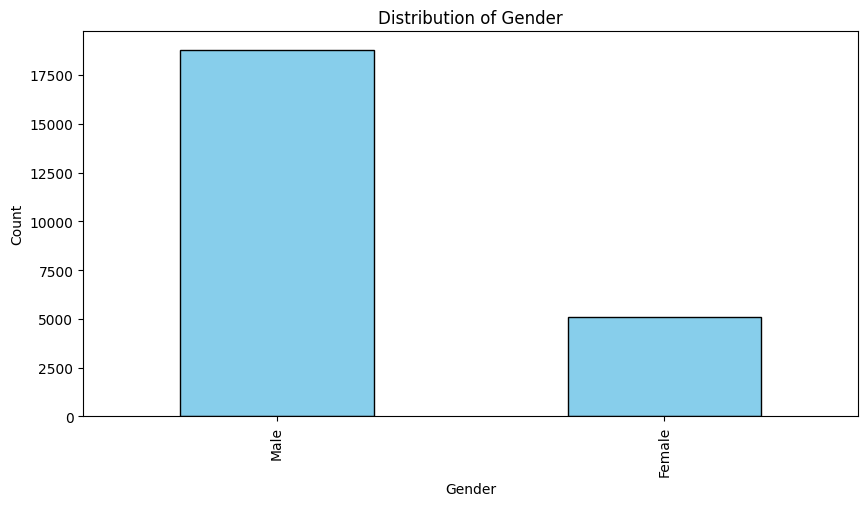

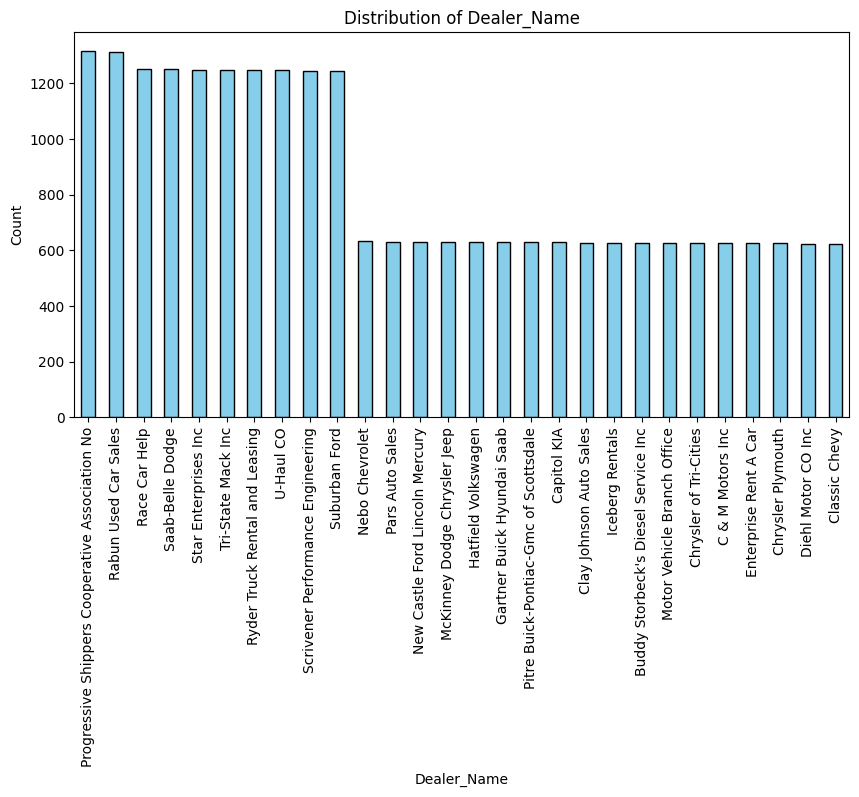

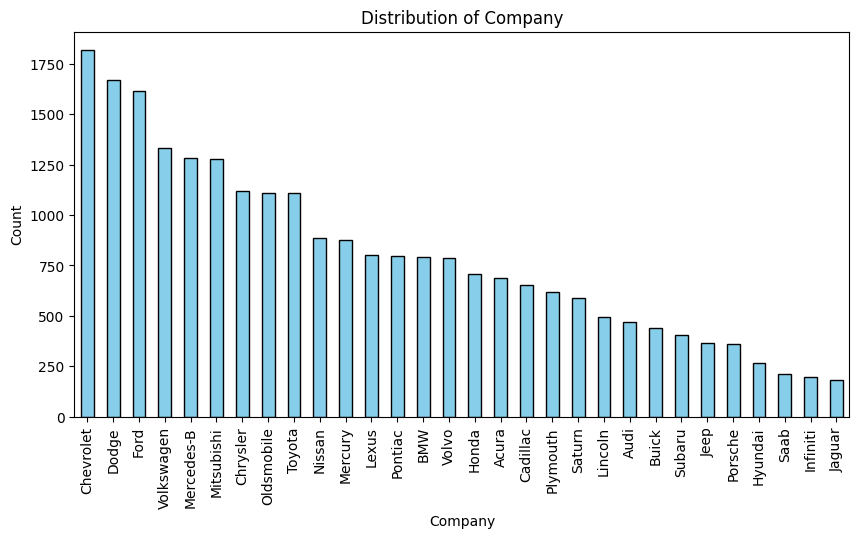

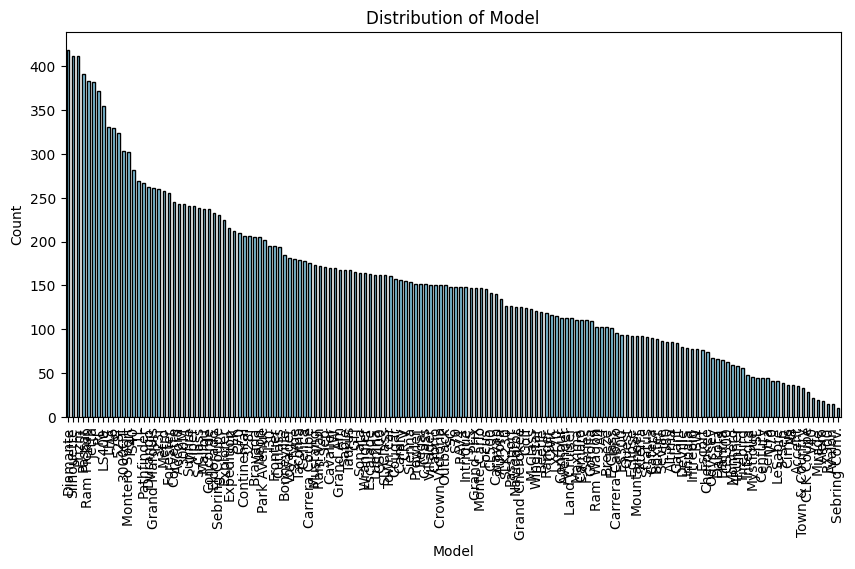

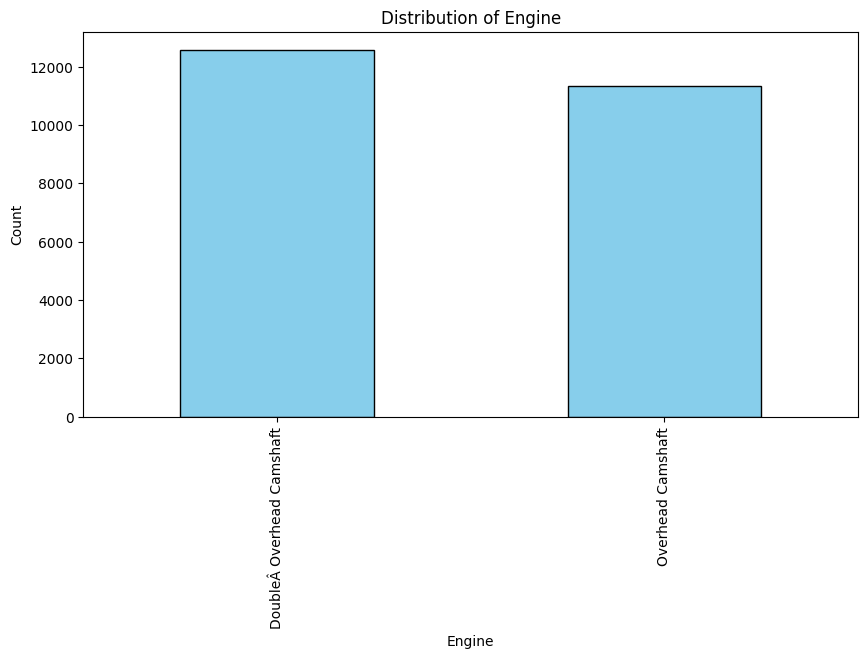

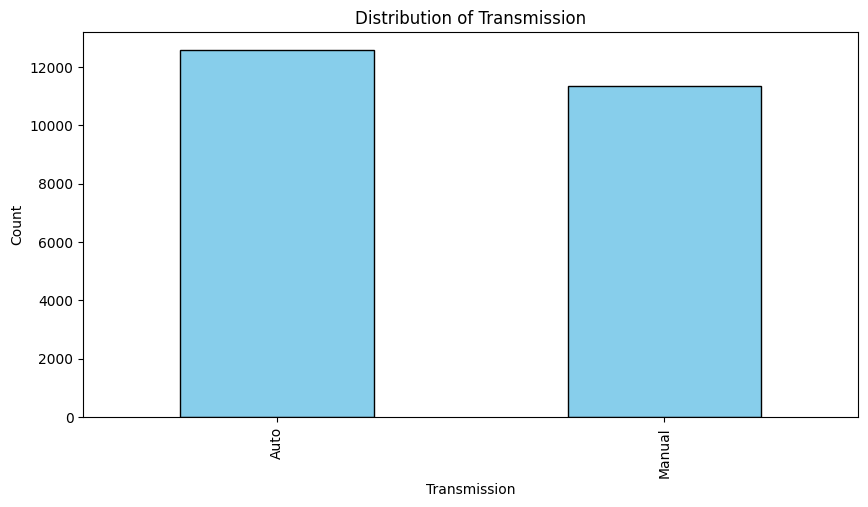

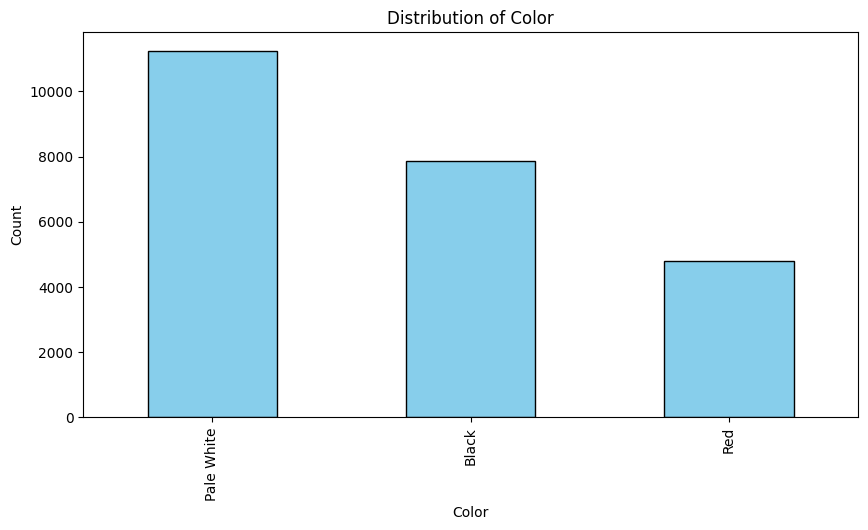

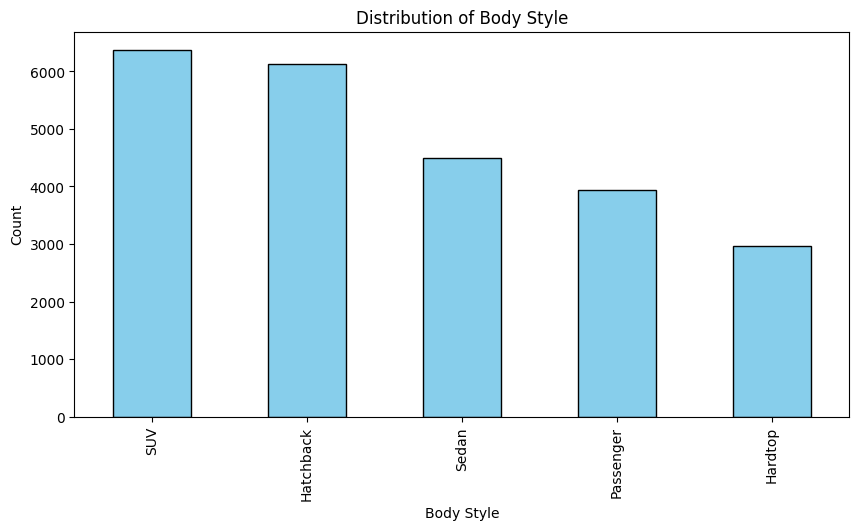

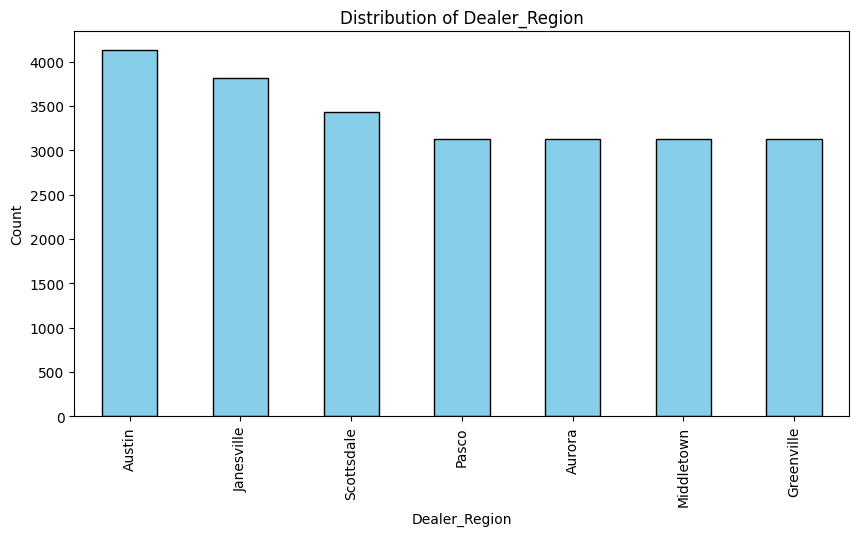

In [24]:
for i in categorical_cols:
  if i!='Annual Income'and  i!='Price ($)':
    plt.figure(figsize=(10, 5))
    df[i].value_counts().plot(kind='bar', color='skyblue', edgecolor='black')
    plt.title(f"Distribution of {i}")
    plt.xlabel(i)
    plt.ylabel("Count")
    plt.show()

Now pi charts for each column

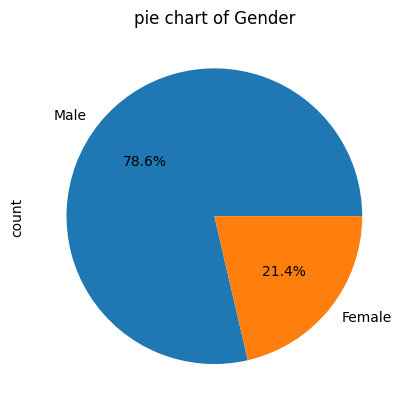

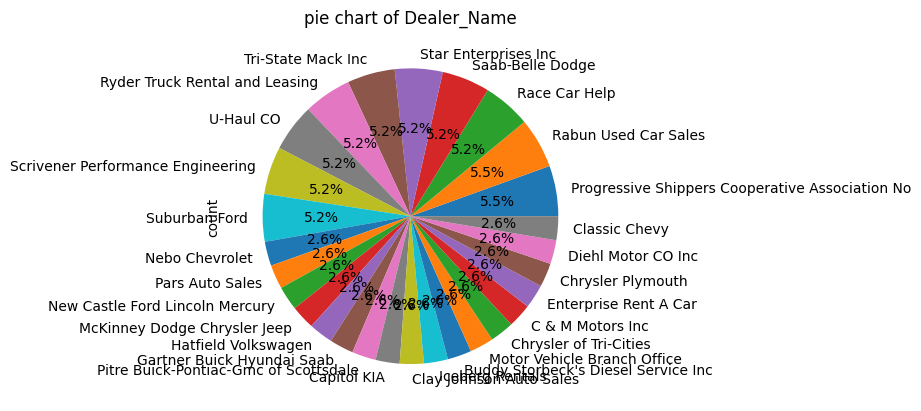

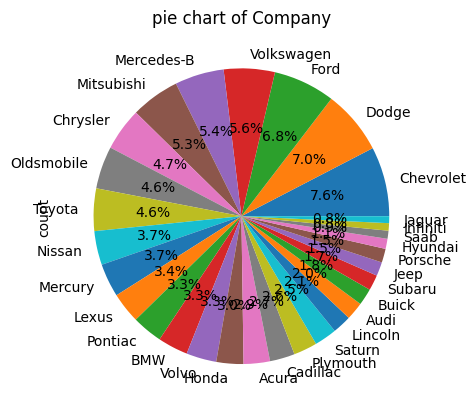

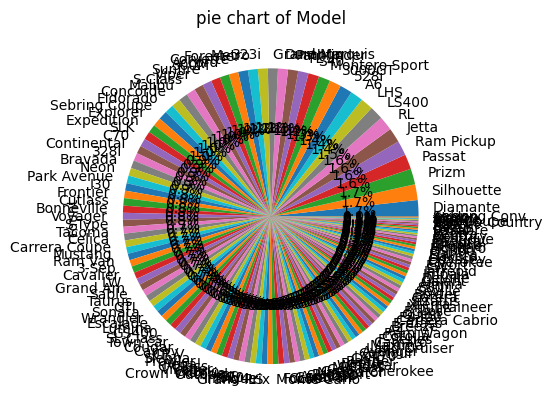

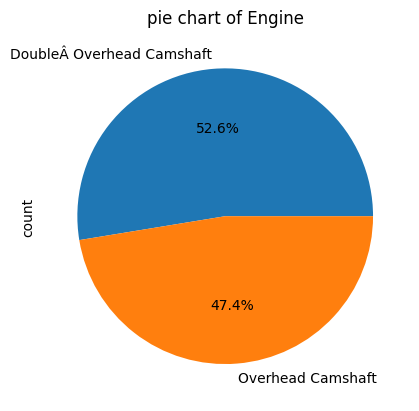

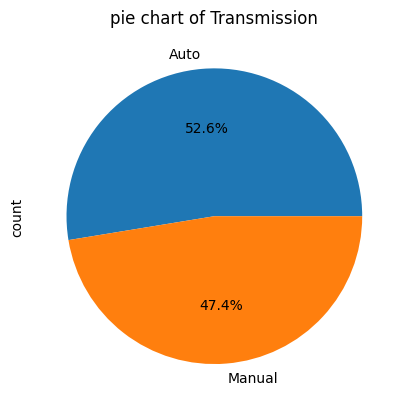

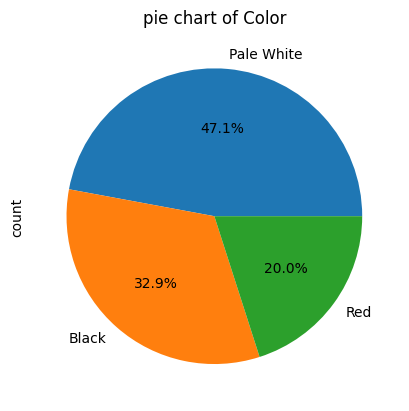

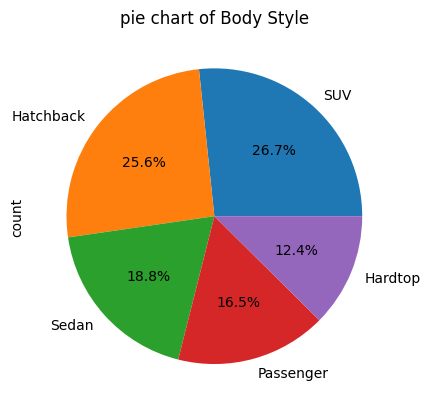

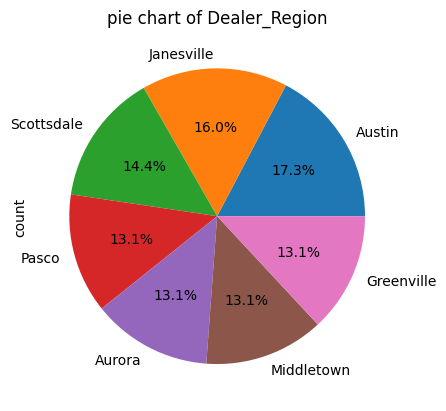

In [25]:
for i in categorical_cols:
  if i!='Annual Income'and  i!='Price ($)':
    df[i].value_counts().plot(kind='pie',autopct='%0.1f%%')
    plt.title(f"pie chart of {i}")
    plt.show()

###numerical columns

printing the mode,mean,median and skew of each column.

In [26]:
for i in numerical_cols:
  mode_value = df[i].mode()[0]
  mean_value = df[i].mean()
  median_value = df[i].median()
  print(f"The mode of {i} is: {mode_value} and the mean is : {mean_value} and the median is: {median_value}")
  if i!="Date":
    skew_value=df[i].skew()
    variance_value = df[i].var()
    print(f"The skew value of {i} is {skew_value} and the variance is {variance_value} ")

The mode of Annual Income is: 13500 and the mean is : 830840.2851167071 and the median is: 735000.0
The skew value of Annual Income is 1.7398383620877993 and the variance is 518409209399.4787 
The mode of Price ($) is: 22000 and the mean is : 28090.247845729107 and the median is: 23000.0
The skew value of Price ($) is 1.4663159398912704 and the variance is 218705281.15977576 
The mode of Year is: 2023 and the mean is : 2022.554714297666 and the median is: 2023.0
The skew value of Year is -0.22019325968991643 and the variance is 0.24701667846272593 
The mode of Month is: 12 and the mean is : 7.852923952145905 and the median is: 9.0
The skew value of Month is -0.41558155476037073 and the variance is 10.614468965310126 
The mode of Day is: 5 and the mean is : 15.473061156195097 and the median is: 15.0
The skew value of Day is 0.03694930138476146 and the variance is 76.28576245072506 


Histogram for each column.

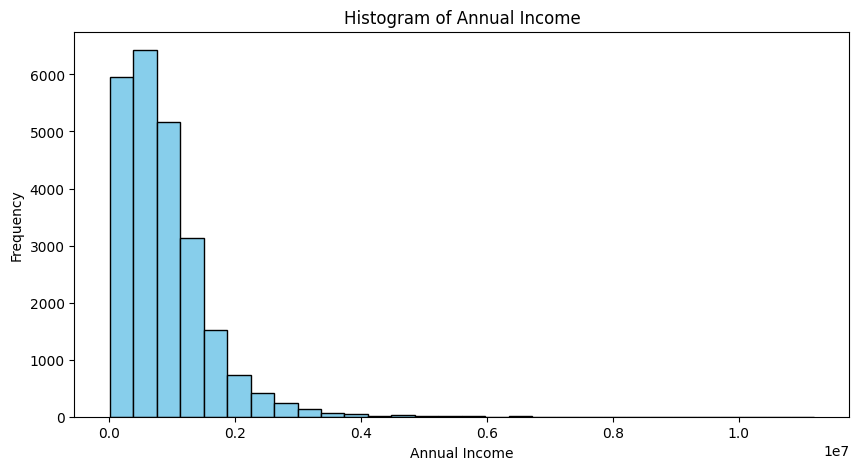

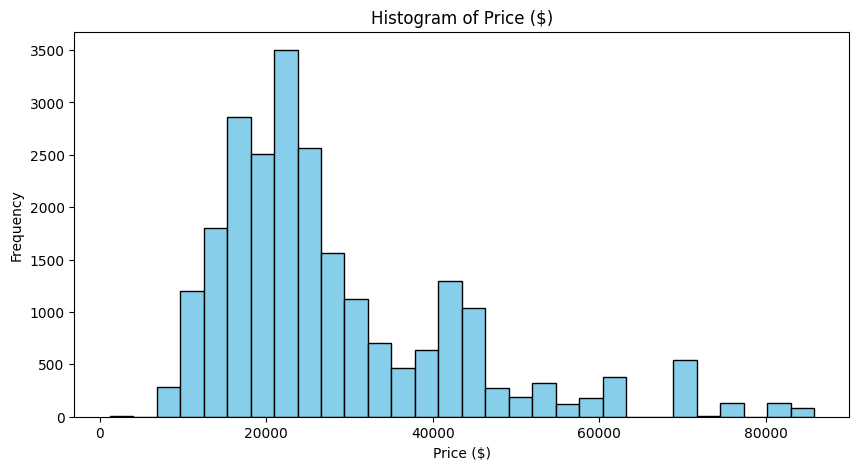

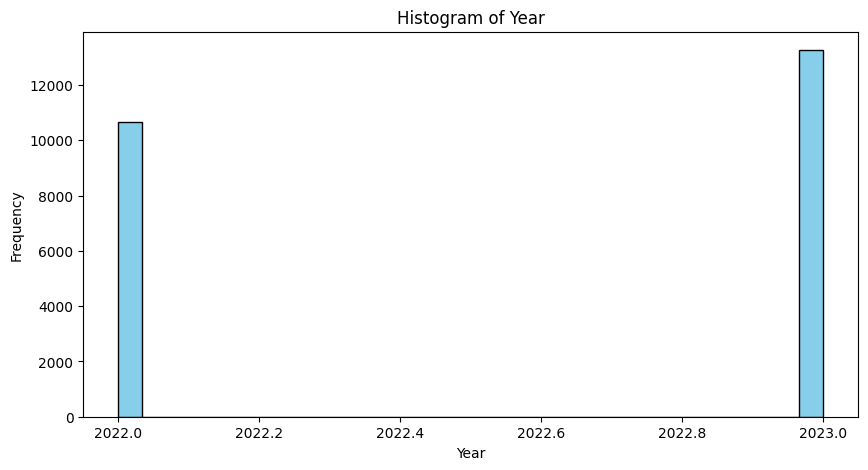

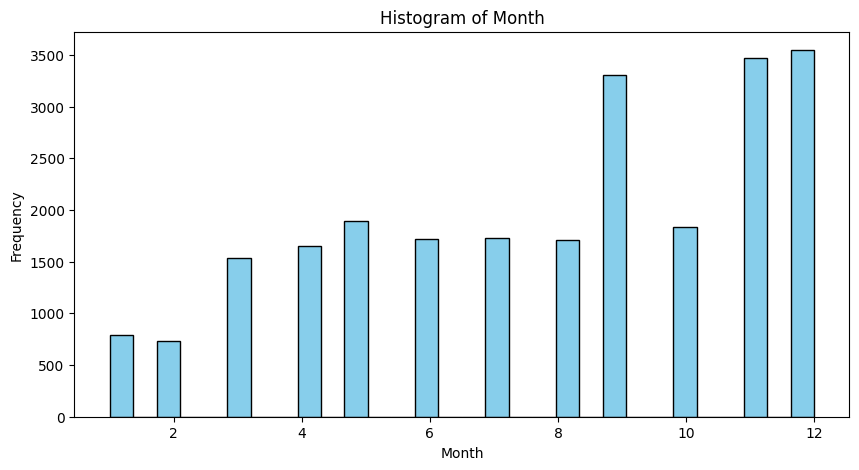

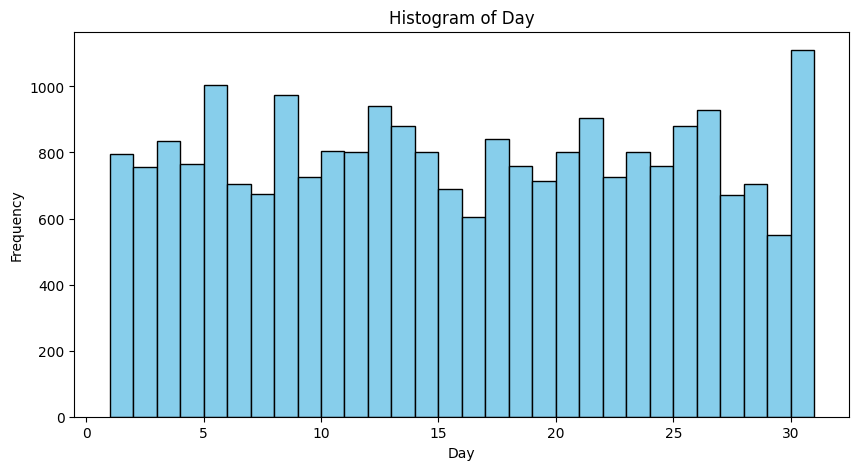

In [27]:
for i in numerical_cols:
    plt.figure(figsize=(10, 5))
    plt.hist(df[i], bins=30, color='skyblue', edgecolor='black')
    plt.title(f"Histogram of {i}")
    plt.xlabel(i)
    plt.ylabel("Frequency")
    plt.show()

KDE plot for each column.

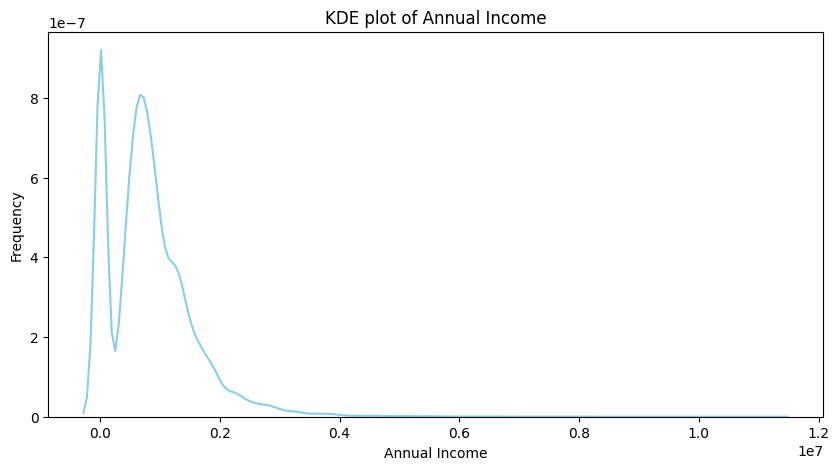

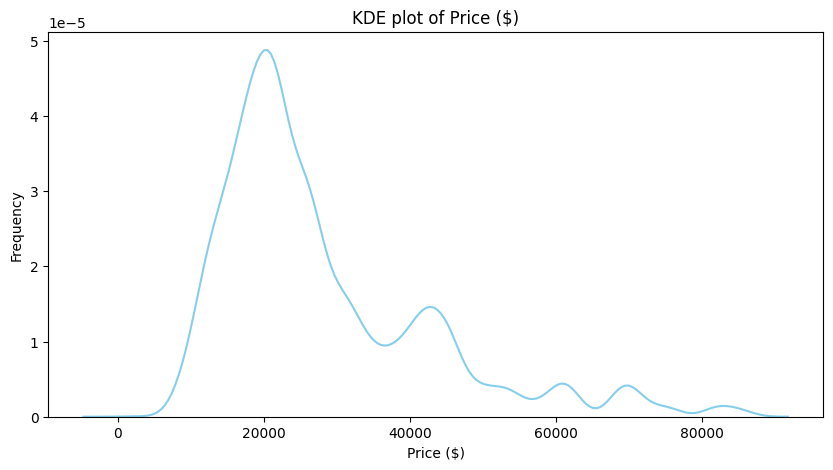

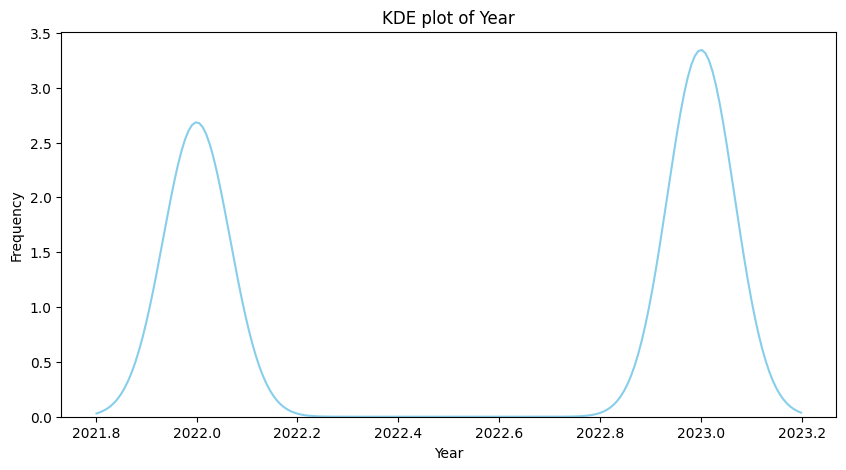

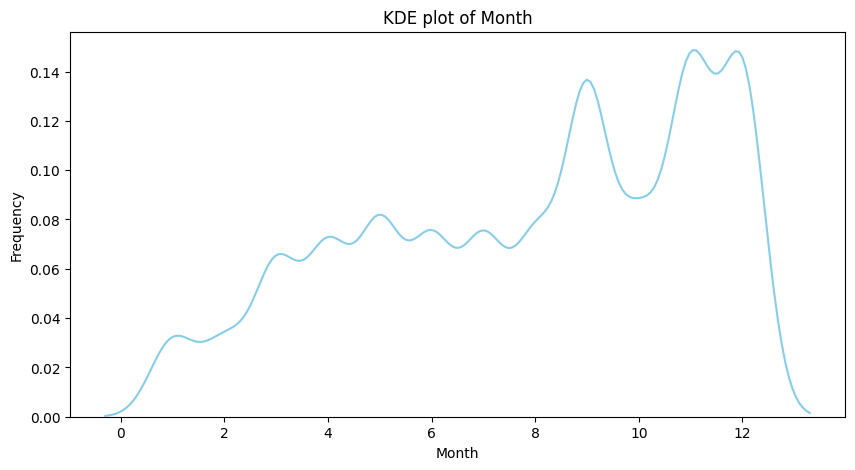

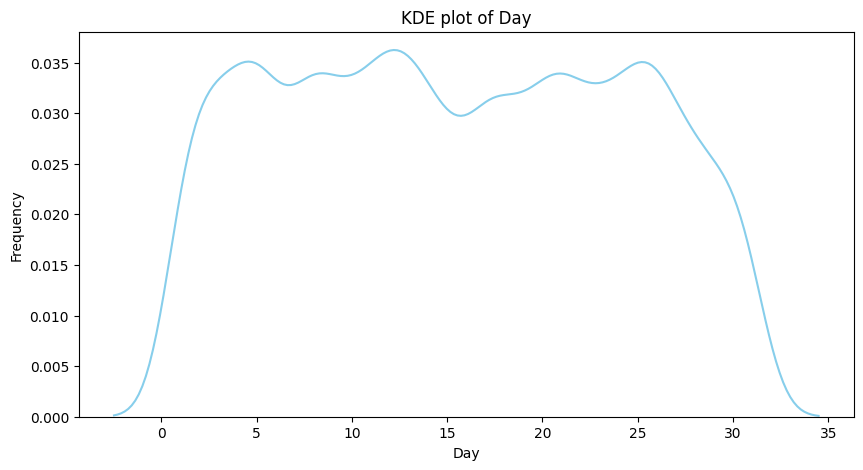

In [28]:
for i in numerical_cols:
    plt.figure(figsize=(10, 5))
    sns.kdeplot(df[i], color='skyblue')
    plt.title(f"KDE plot of {i}")
    plt.xlabel(i)
    plt.ylabel("Frequency")
    plt.show()

Box plots

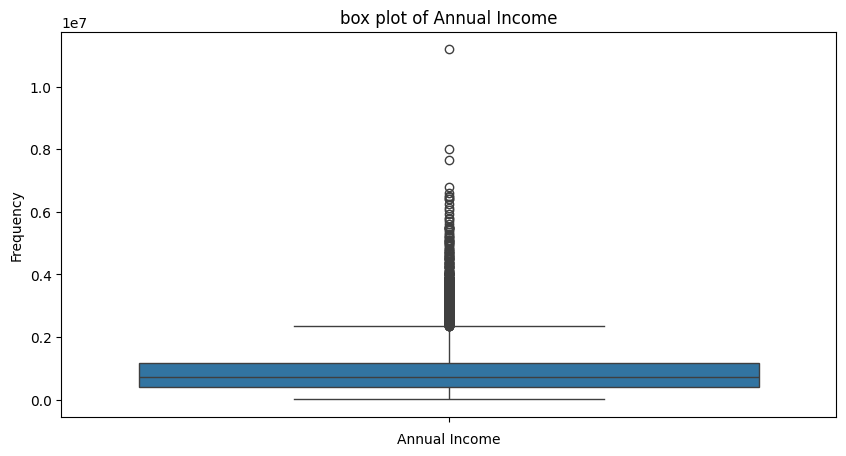

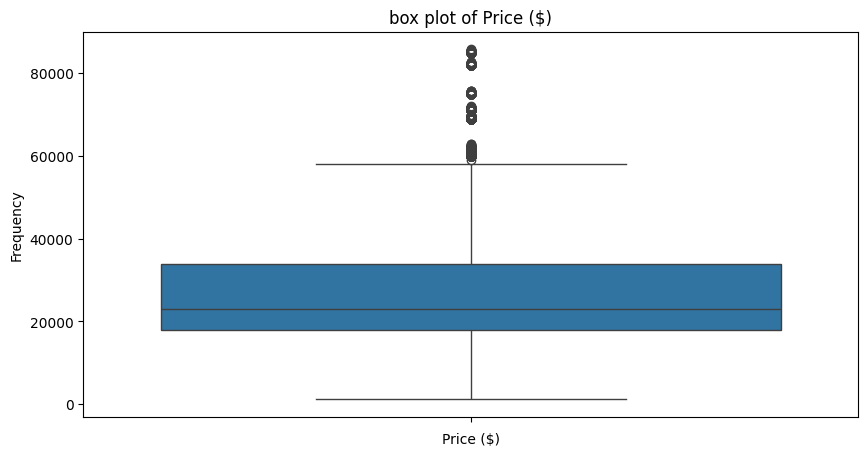

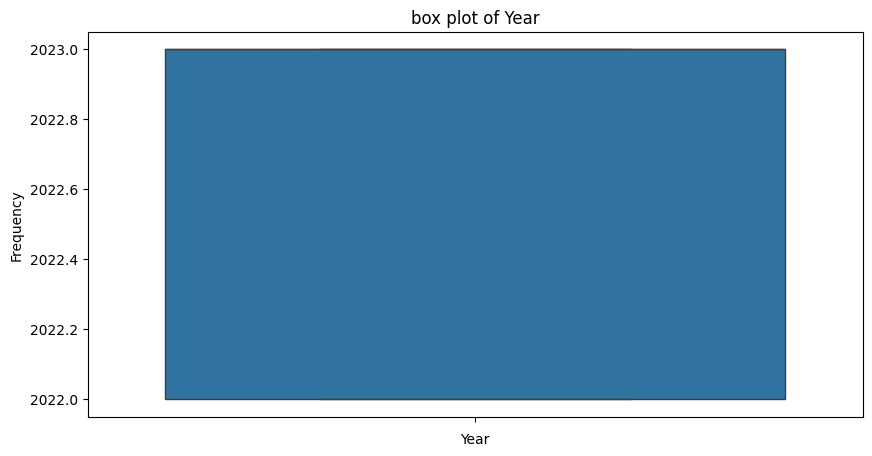

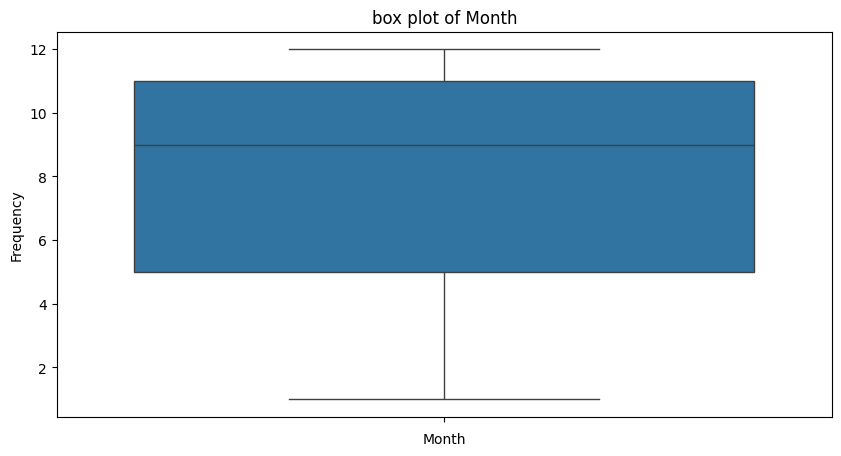

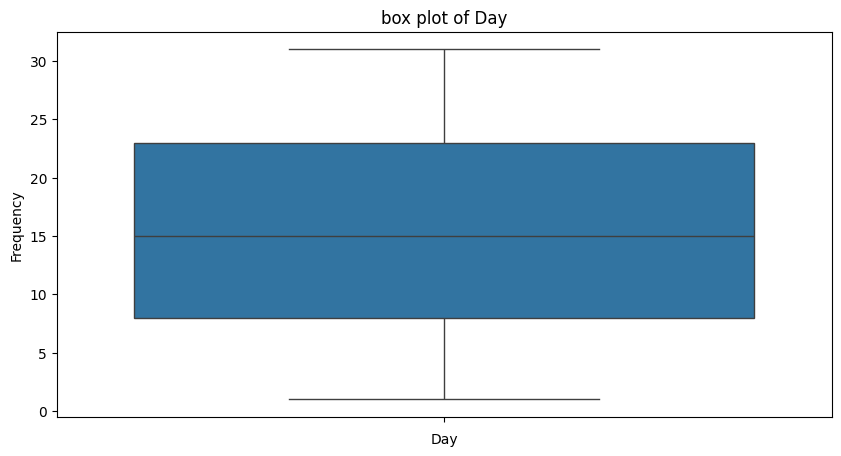

In [29]:
for i in numerical_cols:
    plt.figure(figsize=(10, 5))
    sns.boxplot(df[i])
    plt.title(f"box plot of {i}")
    plt.xlabel(i)
    plt.ylabel("Frequency")
    plt.show()

#Bivariate analysis

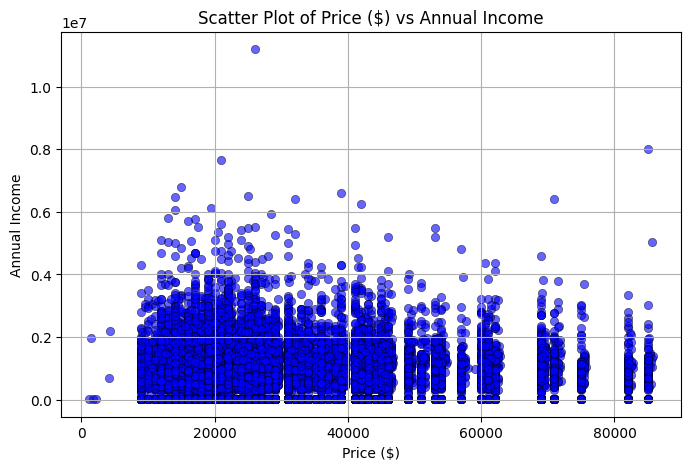

In [30]:
x_col = "Price ($)"   # Replace with actual column name
y_col = "Annual Income"  # Replace with actual column name

# Plot scatter plot
plt.figure(figsize=(8, 5))
sns.scatterplot(x=df[x_col], y=df[y_col], color="blue", alpha=0.6, edgecolor="black")
plt.title(f"Scatter Plot of {x_col} vs {y_col}")
plt.xlabel(x_col)
plt.ylabel(y_col)
plt.grid(True)
plt.show()

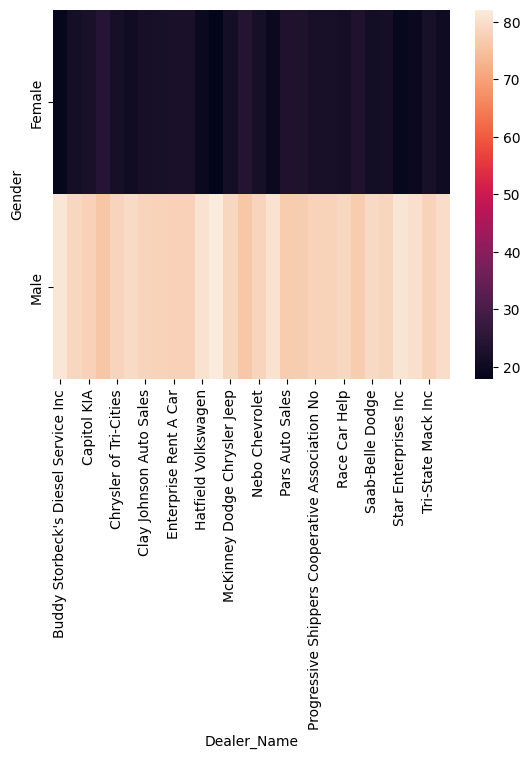

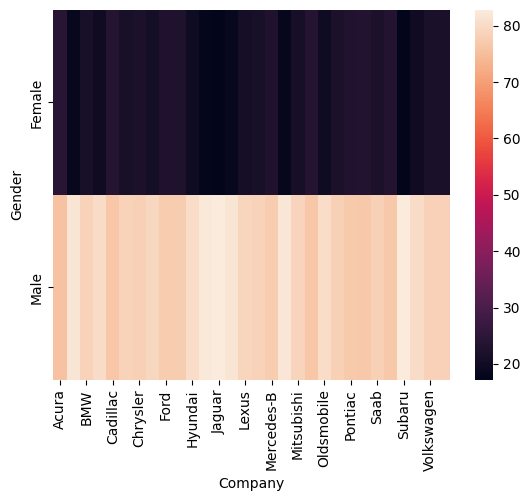

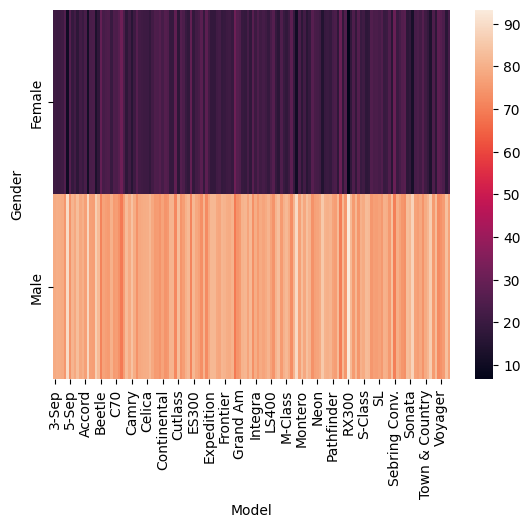

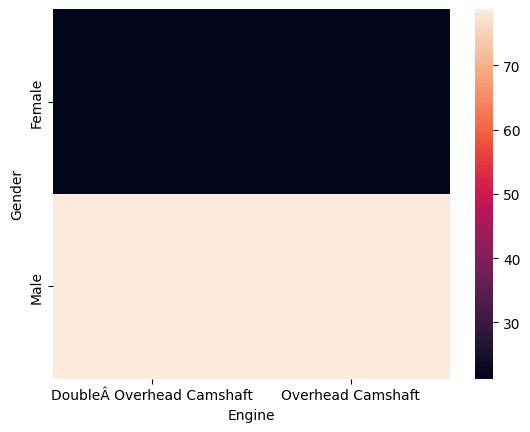

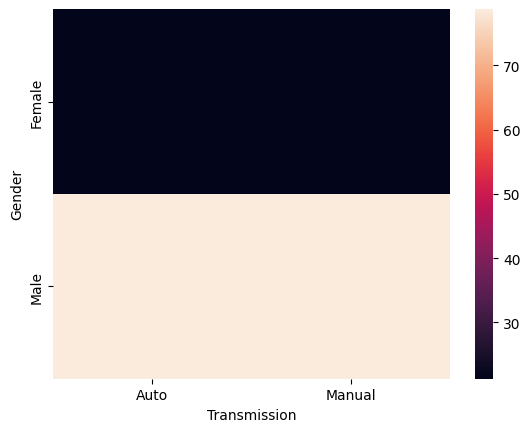

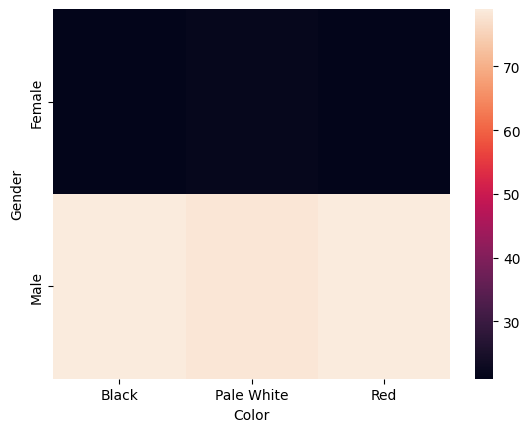

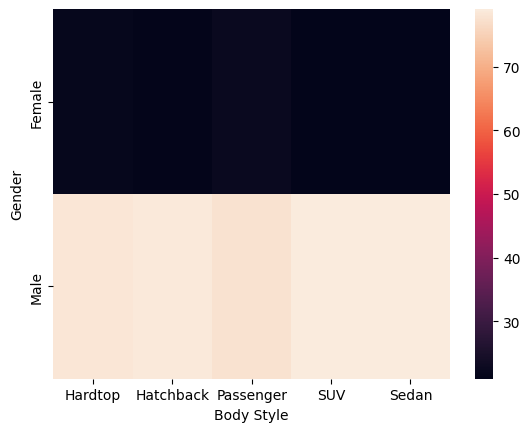

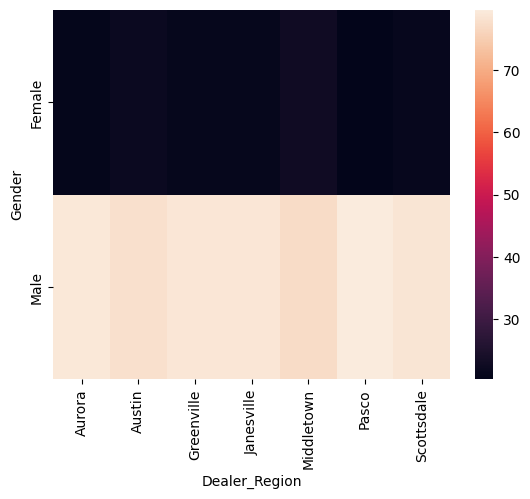

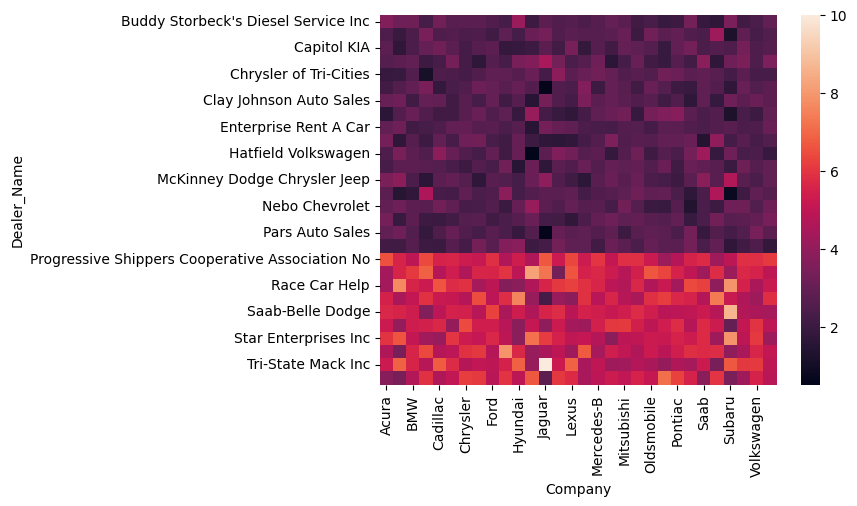

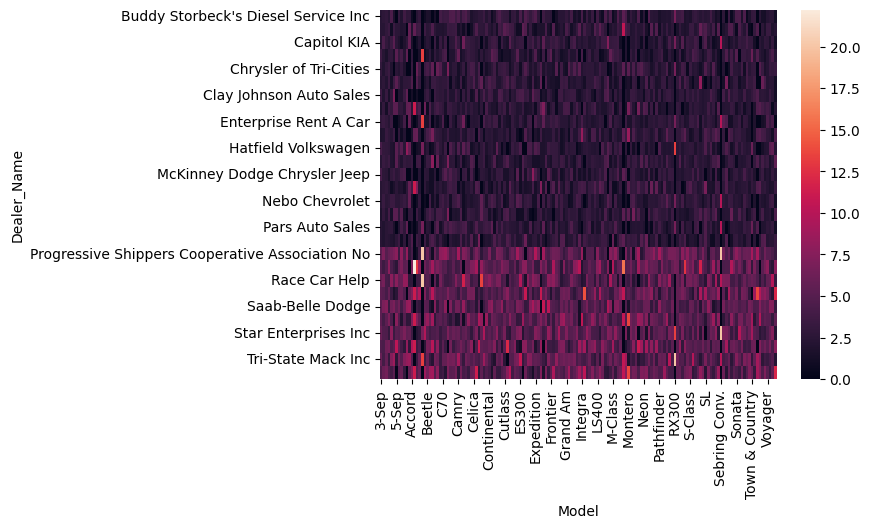

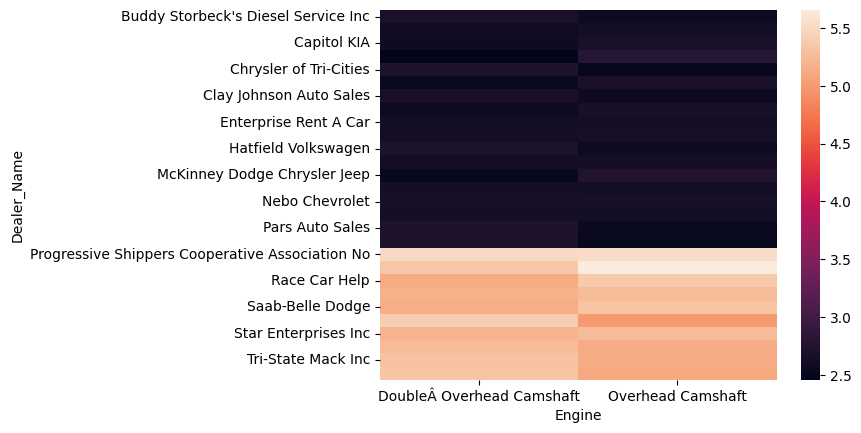

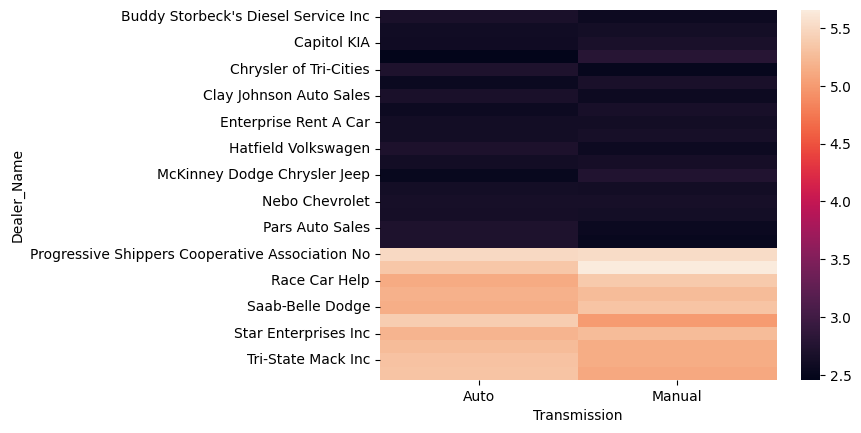

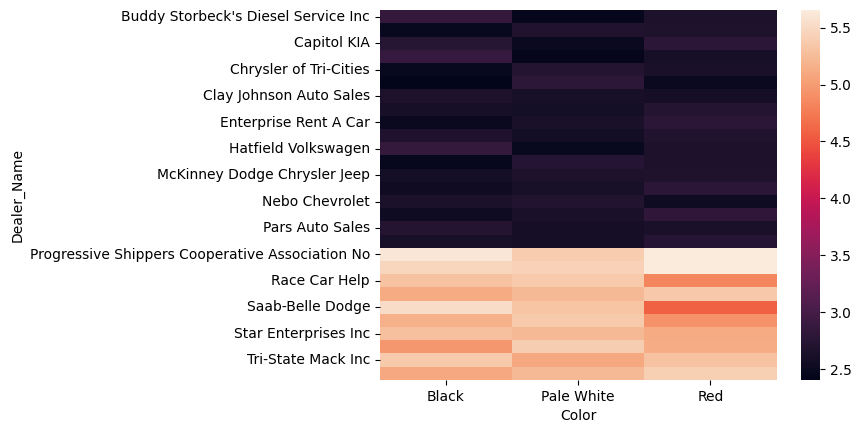

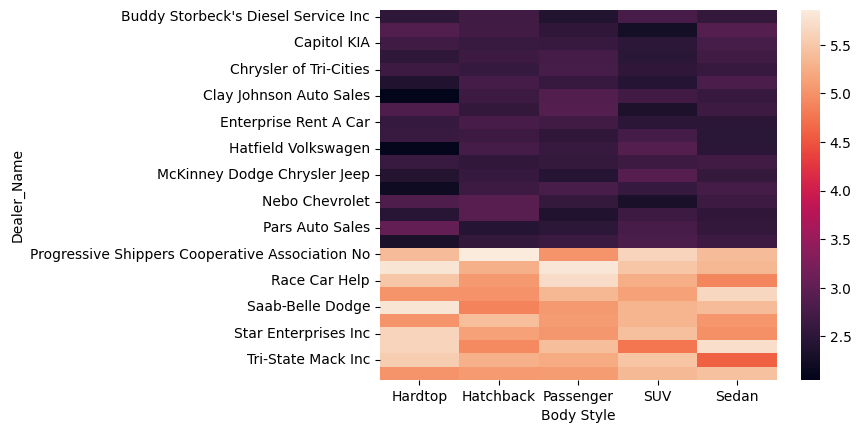

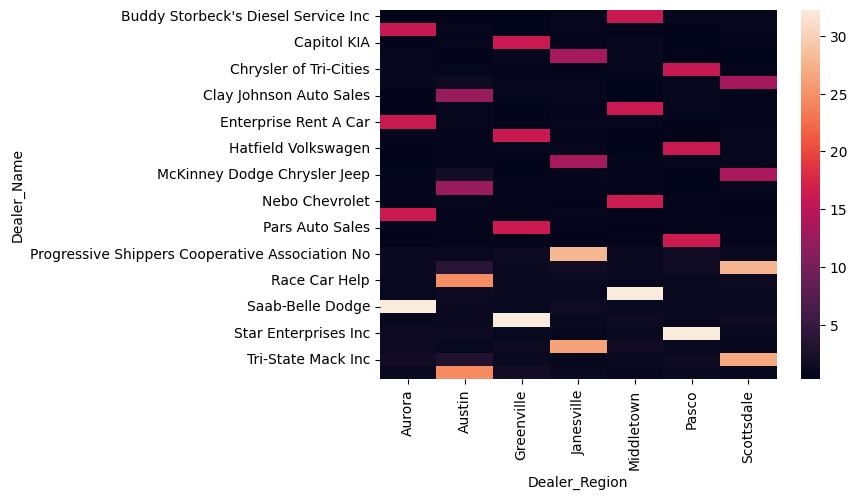

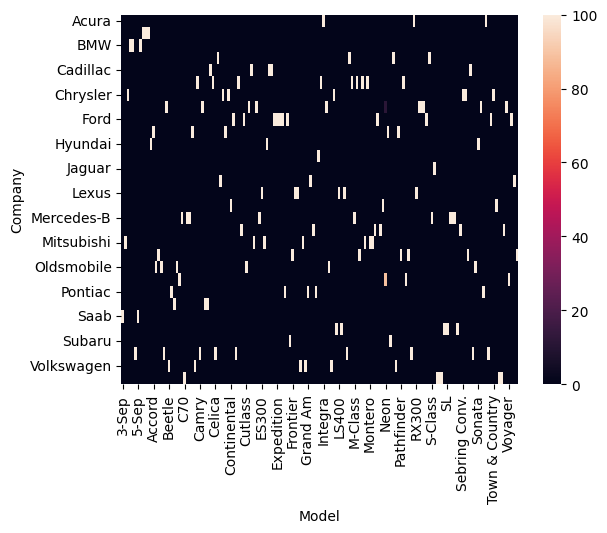

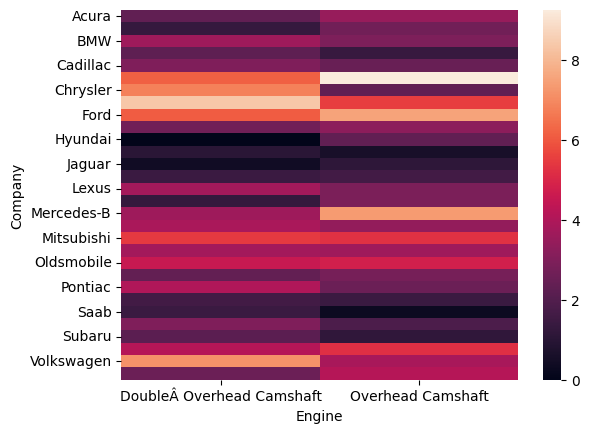

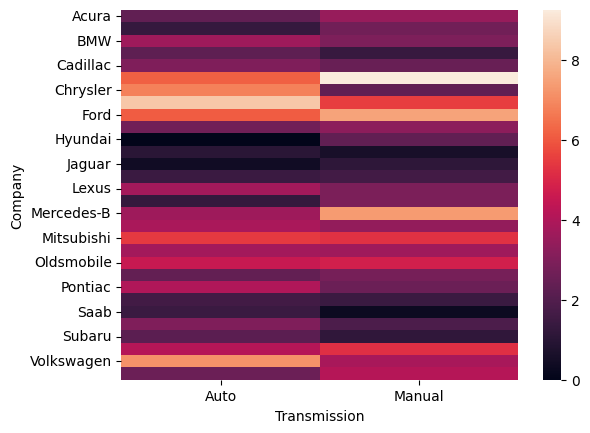

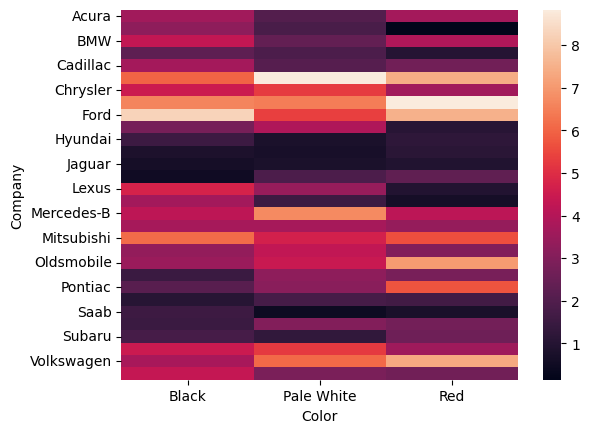

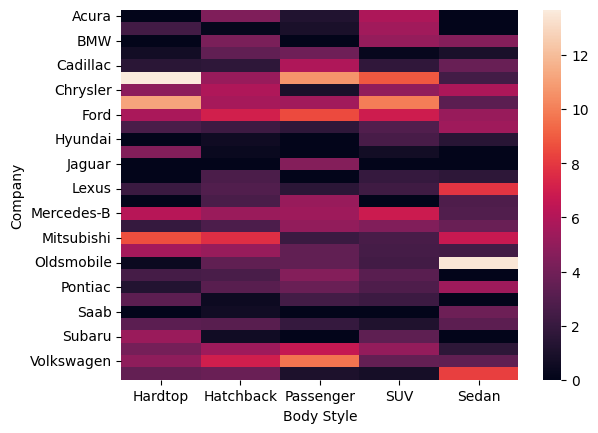

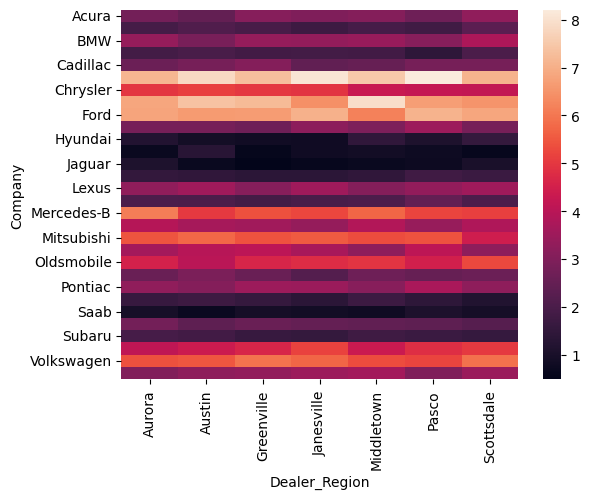

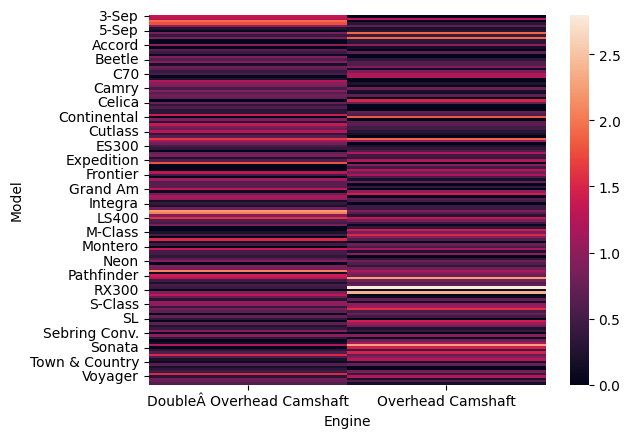

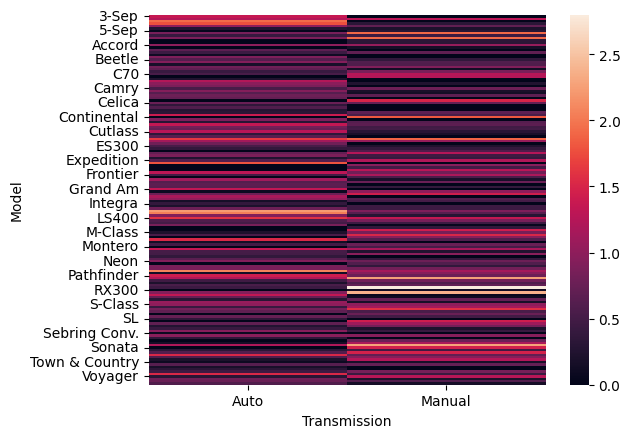

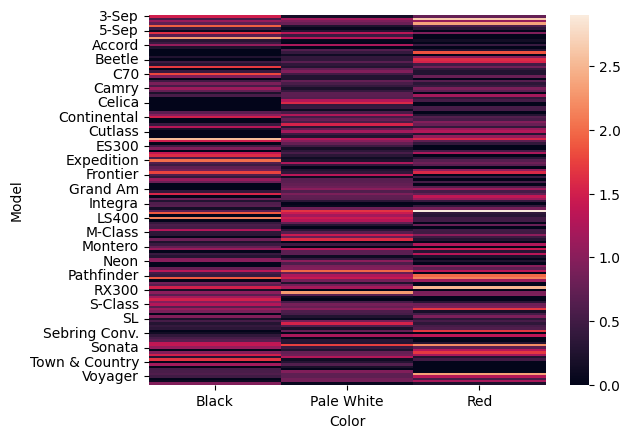

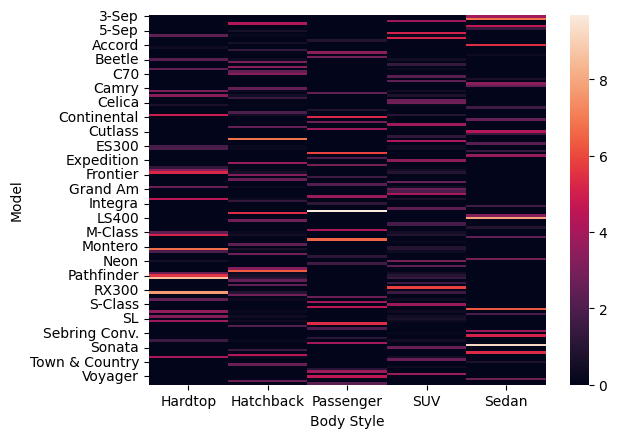

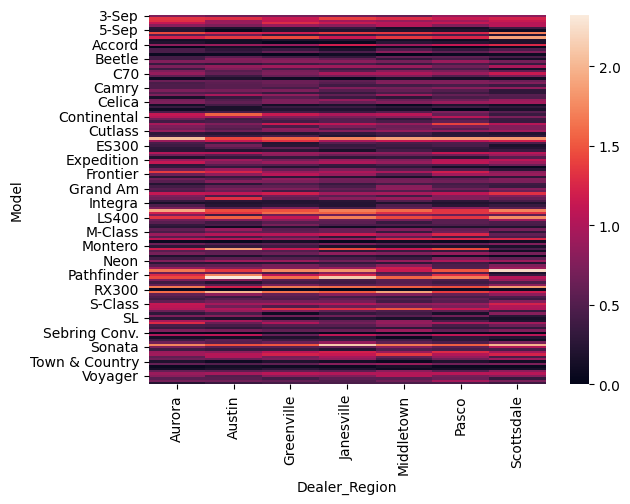

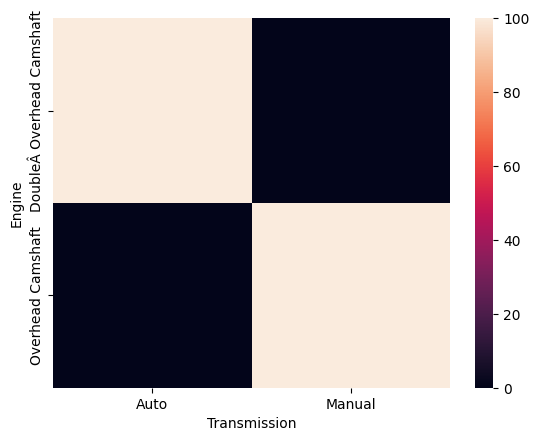

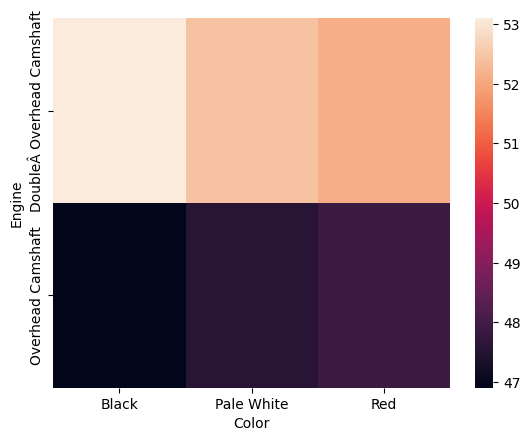

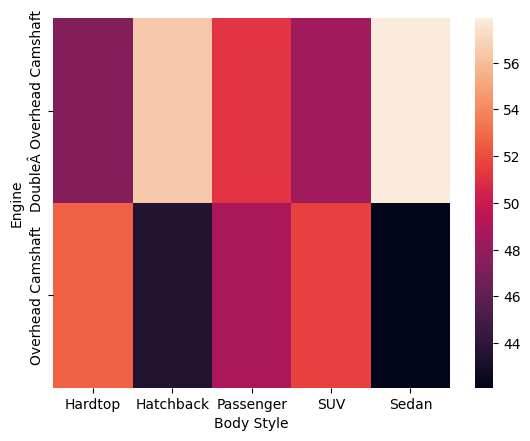

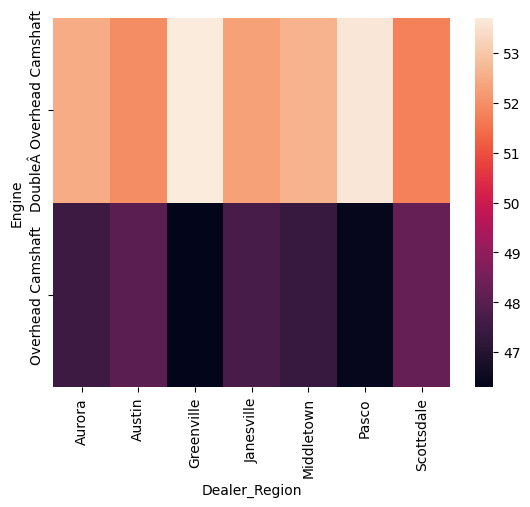

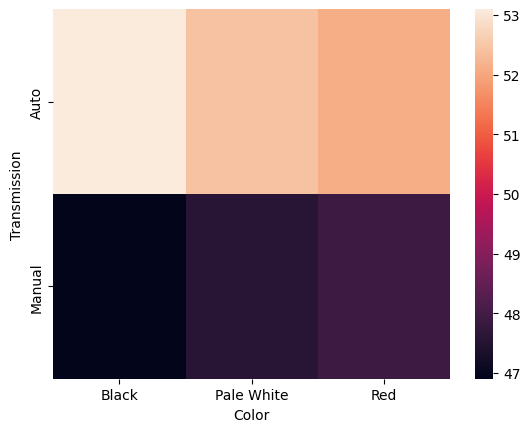

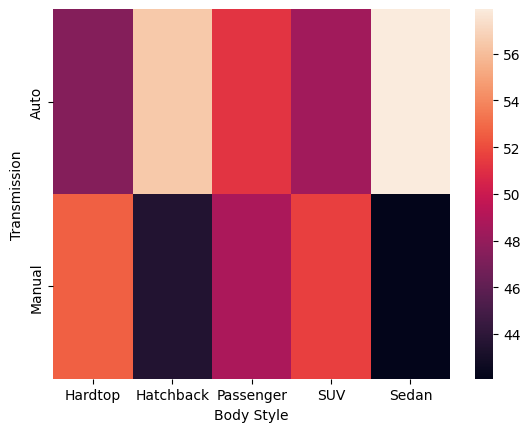

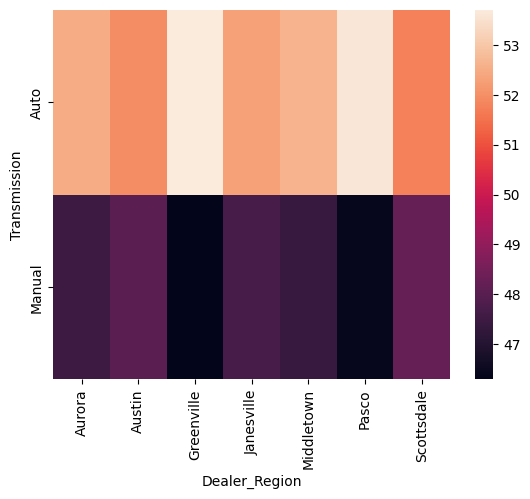

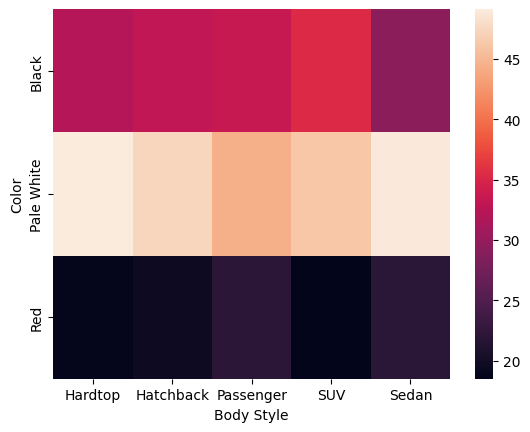

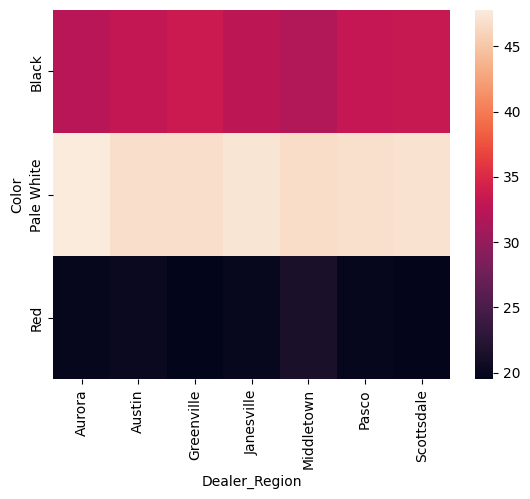

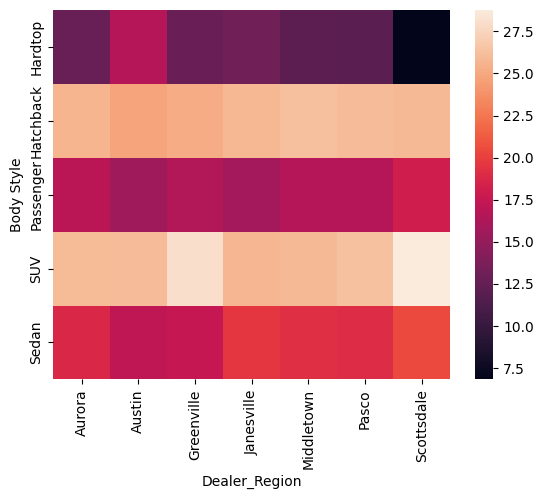

In [31]:
for i in range(0,9):
  for j in range(i+1,9):
    if(i!=j):
      sns.heatmap(pd.crosstab(df[categorical_cols[i]],df[categorical_cols[j]],normalize='columns')*100)
      plt.show()

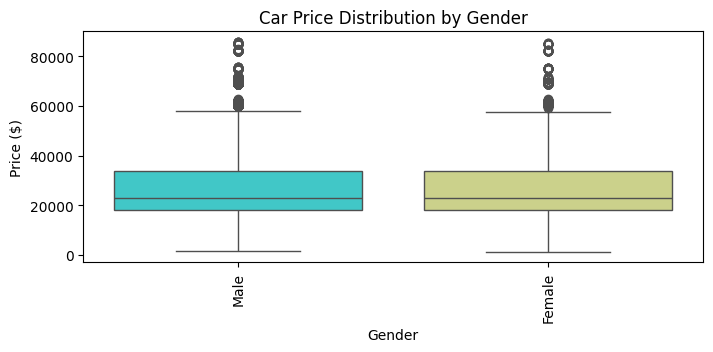

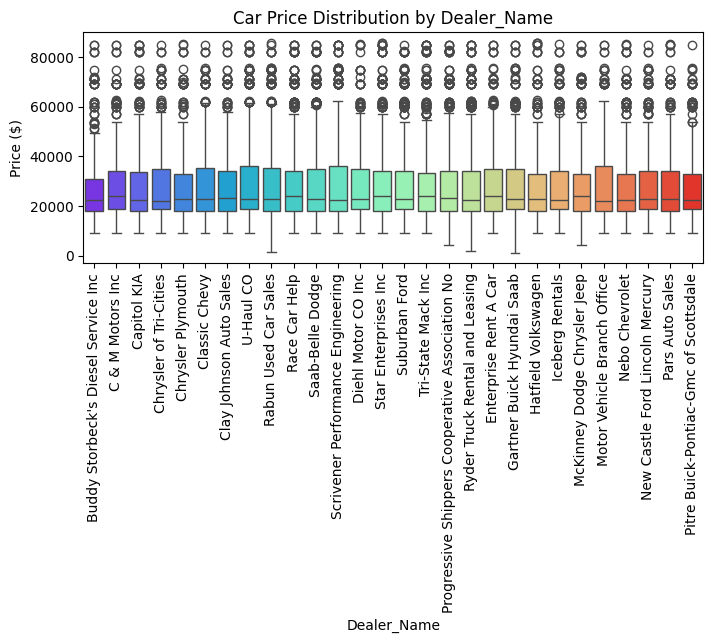

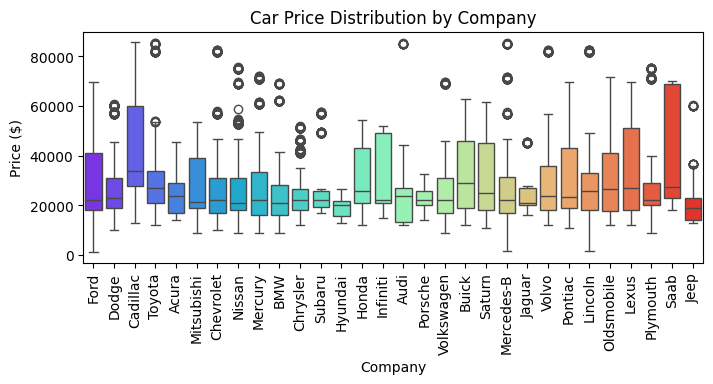

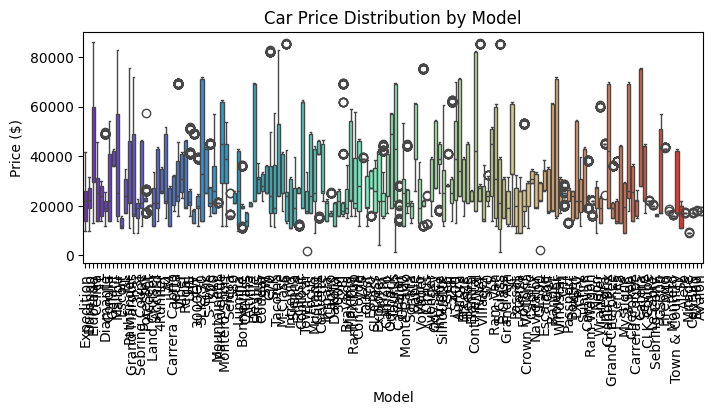

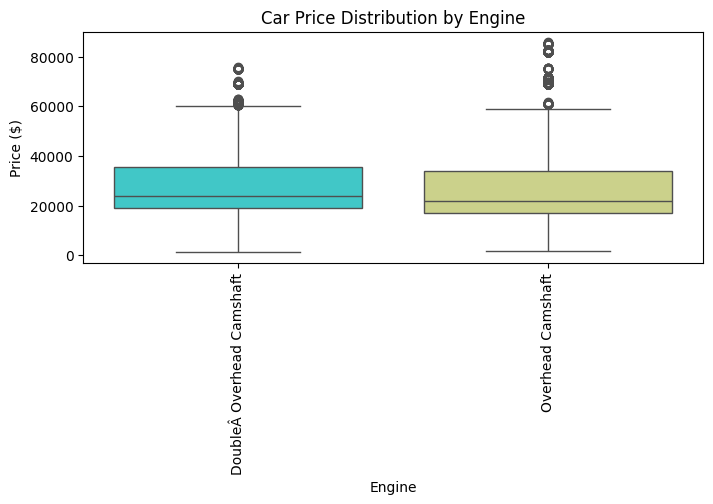

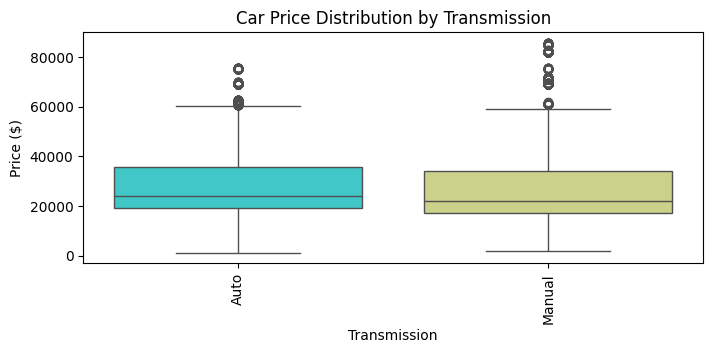

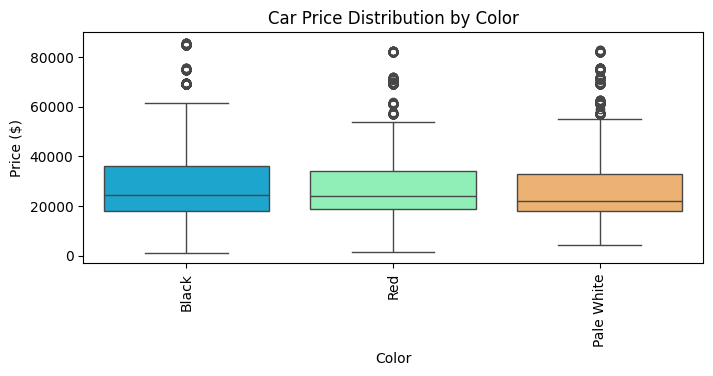

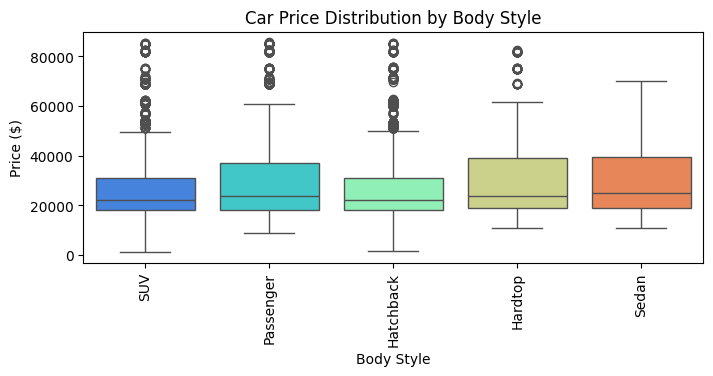

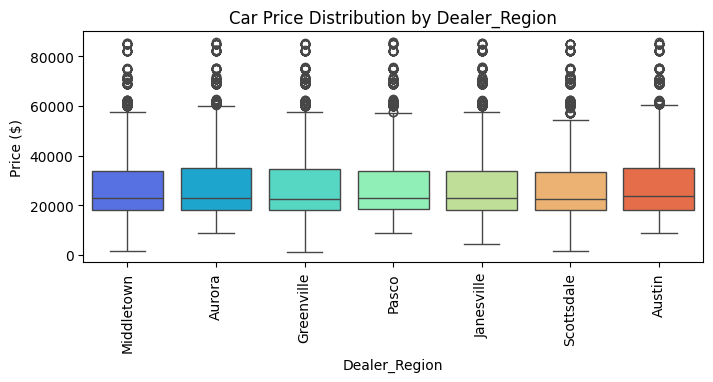

In [32]:
for i in categorical_cols:
  plt.figure(figsize=(8,3))
  sns.boxplot(x=i, y='Price ($)', hue=i,data=df, palette='rainbow')
  plt.title(f'Car Price Distribution by {i}')
  plt.xticks(rotation=90)
  plt.show()

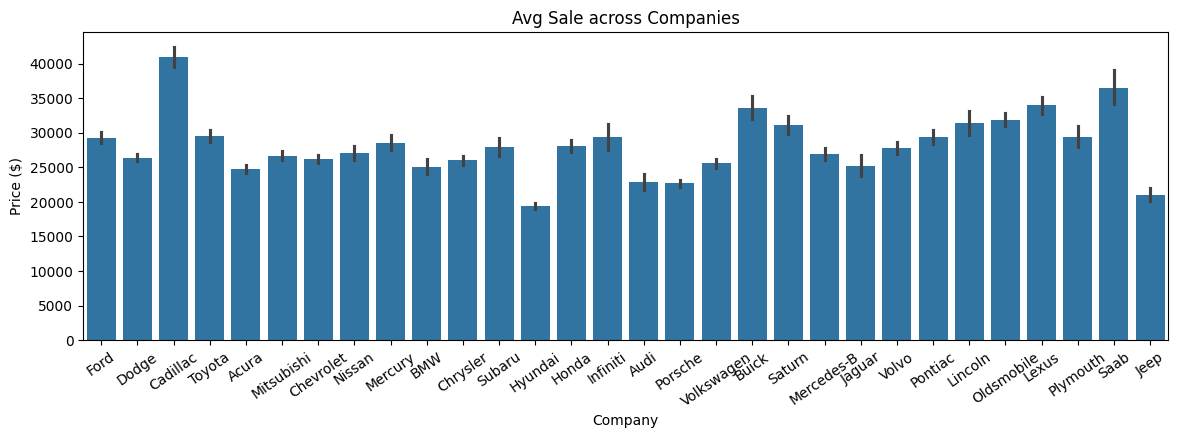

In [33]:
plt.figure(figsize=(14,4))
sns.barplot(x='Company',y='Price ($)', data=df)
plt.title('Avg Sale across Companies')
plt.xticks(rotation=35)
plt.show()

In [34]:
result=df.groupby('Company').agg(
    min_price=('Price ($)', 'min'),
    max_price=('Price ($)', 'max'),
    price_range=('Price ($)', lambda x: x.max() - x.min()),
    mean_price=('Price ($)', 'mean'),
    median_price=('Price ($)', 'median'),
    count_sales=('Price ($)', 'count'),
    std_price=('Price ($)', 'std')
).reset_index()

result

,Company,min_price,max_price,price_range,mean_price,median_price,count_sales,std_price
0,Acura,14000,45501,31501,24758.561684,24000.0,689,8183.046414
1,Audi,12000,85500,73500,22851.790598,24000.0,468,12904.243867
2,BMW,9000,69500,60500,25090.622785,21000.0,790,15065.578723
3,Buick,12000,62801,50801,33634.362187,29000.0,439,17142.232626
4,Cadillac,13000,85800,72800,40972.093558,34000.0,652,19517.120220
5,Chevrolet,10000,82800,72800,26198.606377,22000.0,1819,13311.063223
6,Chrysler,12000,51800,39800,26019.529464,22000.0,1120,11583.286811
7,Dodge,10000,60851,50851,26406.341113,23000.0,1671,11187.592085
8,Ford,1200,69600,68400,29263.682156,22225.5,1614,15849.090227
9,Honda,12000,54501,42501,28082.959040,26000.0,708,11148.629062


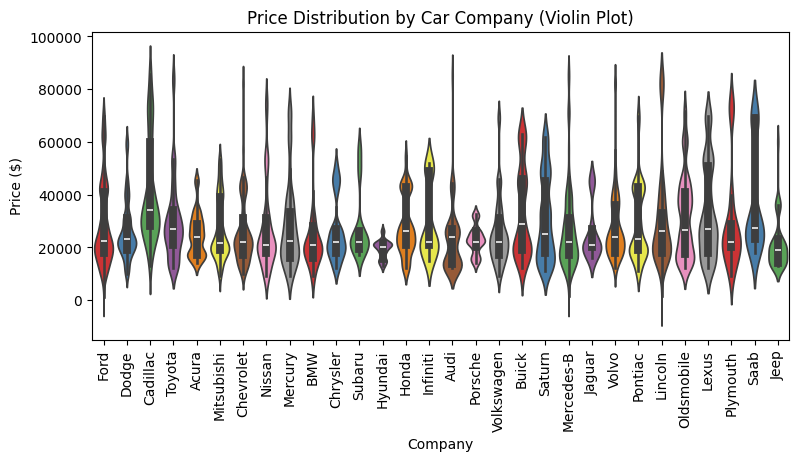

In [35]:
plt.figure(figsize=(9,4))
sns.violinplot(data=df, x='Company', y='Price ($)',hue='Company', palette='Set1')
plt.title('Price Distribution by Car Company (Violin Plot)')
plt.xticks(rotation=90)
plt.show()

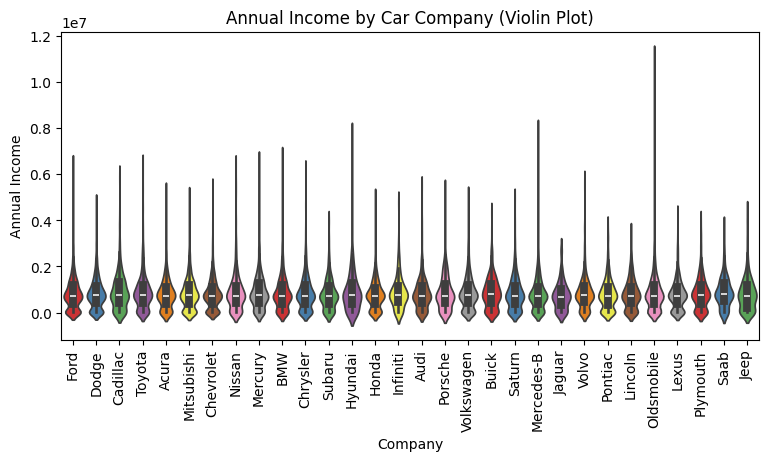

In [36]:
plt.figure(figsize=(9,4))
sns.violinplot(data=df, x='Company', y='Annual Income',hue='Company', palette='Set1')
plt.title('Annual Income by Car Company (Violin Plot)')
plt.xticks(rotation=90)
plt.show()

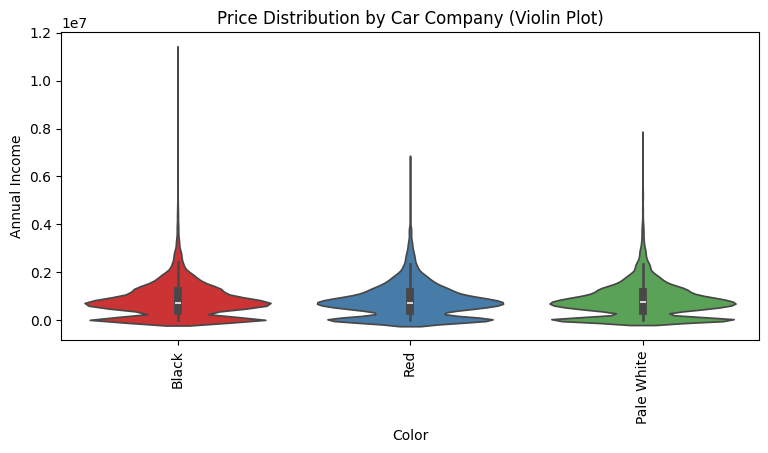

In [37]:
plt.figure(figsize=(9,4))
sns.violinplot(data=df, x='Color', y='Annual Income',hue='Color', palette='Set1')
plt.title('Price Distribution by Car Company (Violin Plot)')
plt.xticks(rotation=90)
plt.show()

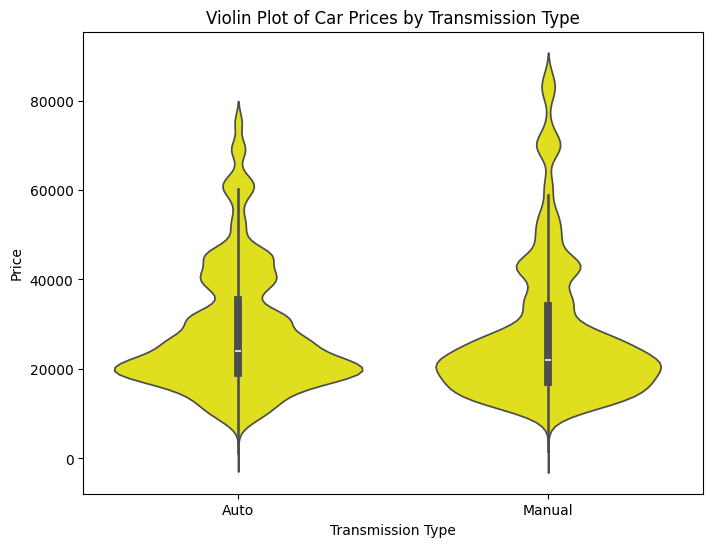

In [38]:
plt.figure(figsize=(8,6))
sns.violinplot(x='Transmission', y='Price ($)', data=df,color='yellow')
plt.title('Violin Plot of Car Prices by Transmission Type')
plt.ylabel('Price')
plt.xlabel('Transmission Type')
plt.show()

#Multivariable Analysis

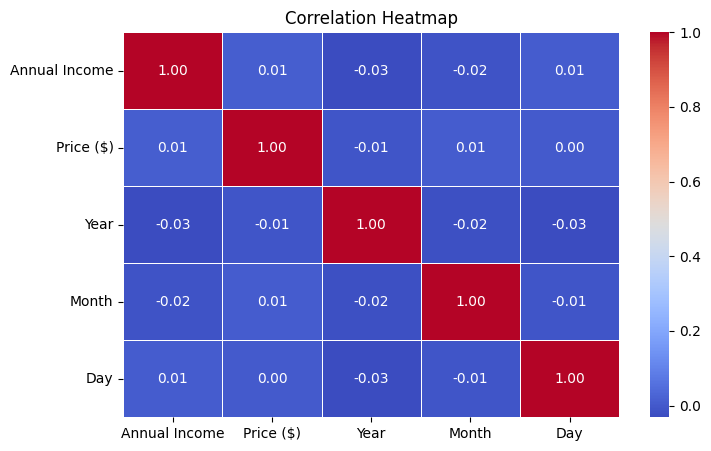

In [39]:
correlation_matrix = df[numerical_cols].corr()
plt.figure(figsize=(8, 5))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

<Figure size 800x300 with 0 Axes>

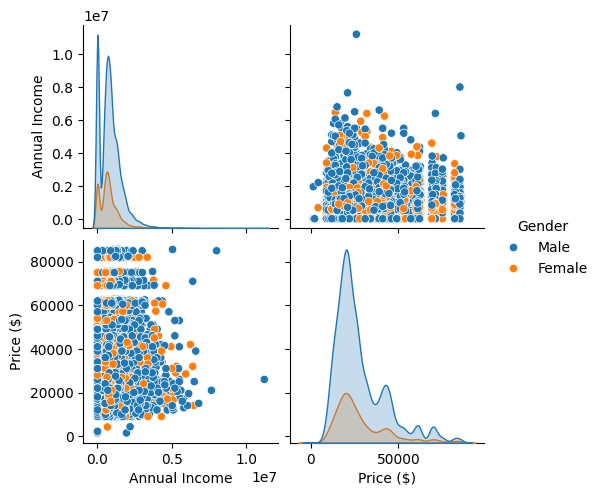

<Figure size 800x300 with 0 Axes>

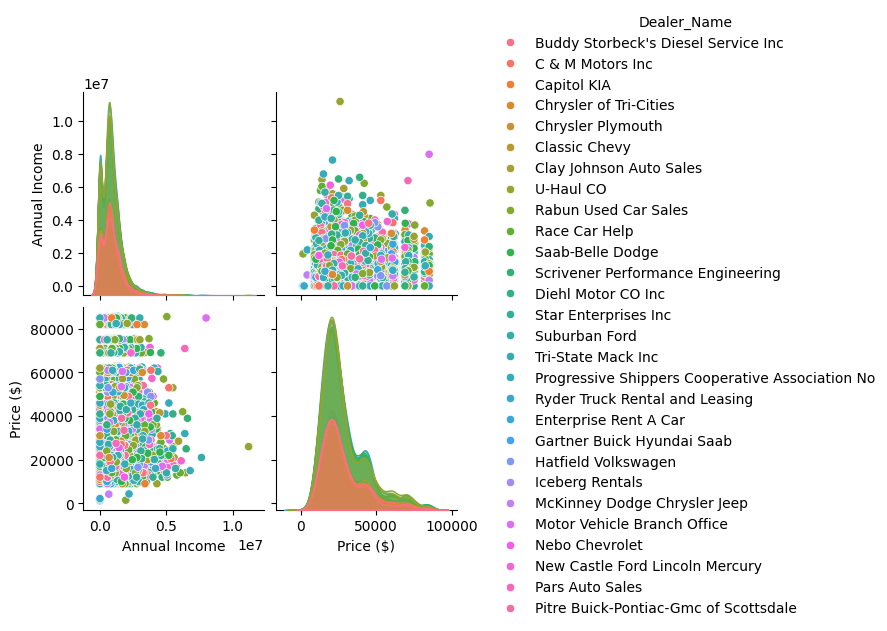

<Figure size 800x300 with 0 Axes>

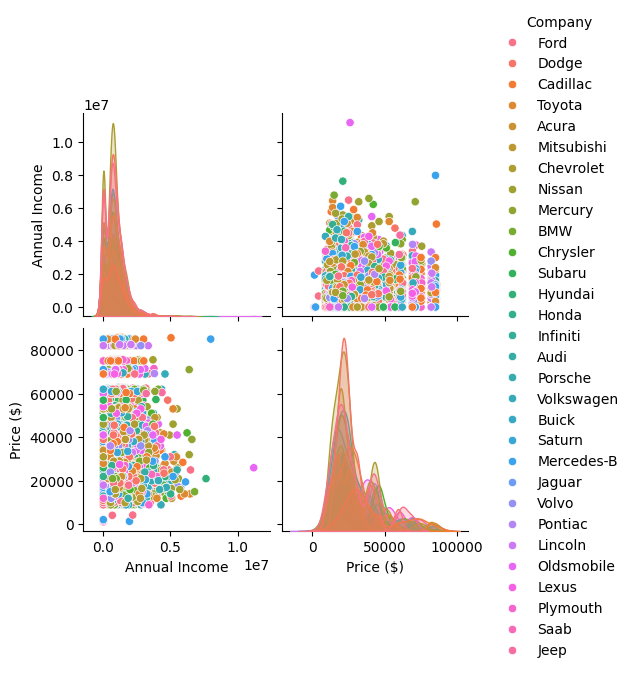

<Figure size 800x300 with 0 Axes>

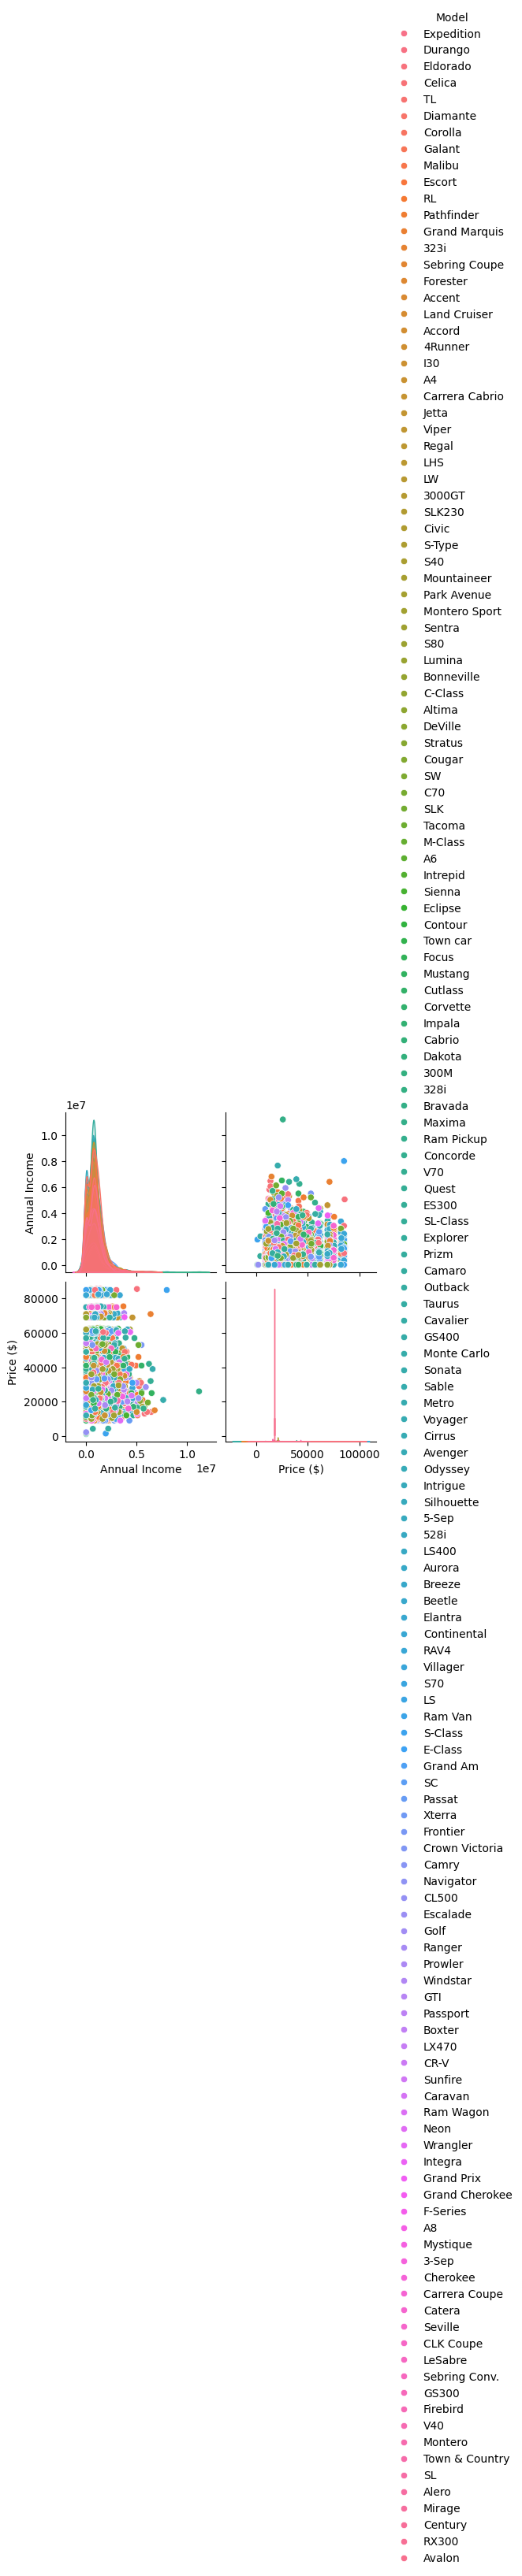

<Figure size 800x300 with 0 Axes>

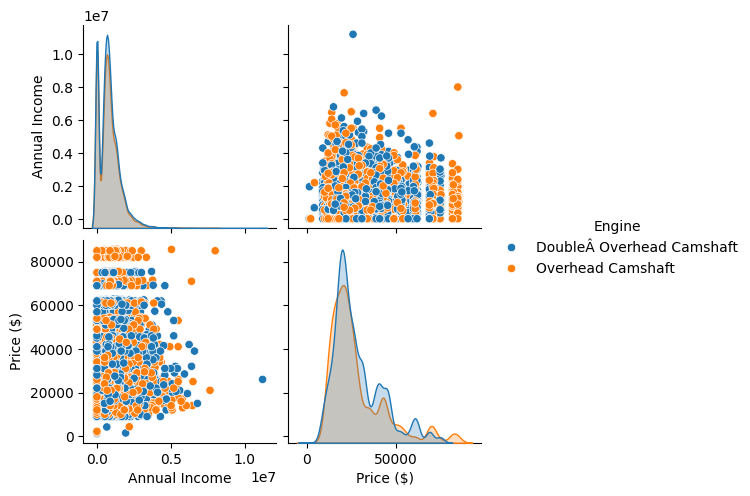

<Figure size 800x300 with 0 Axes>

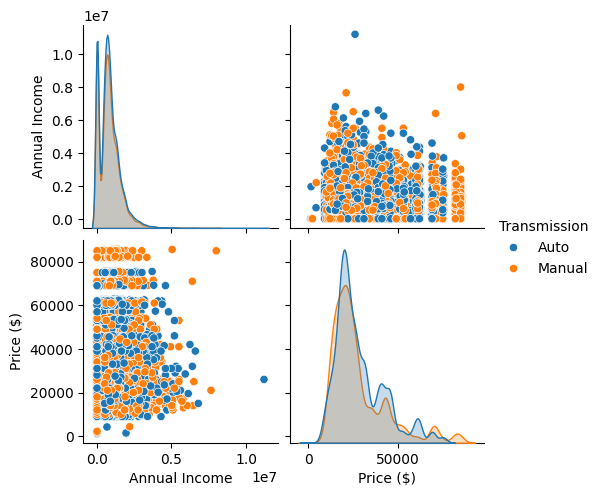

<Figure size 800x300 with 0 Axes>

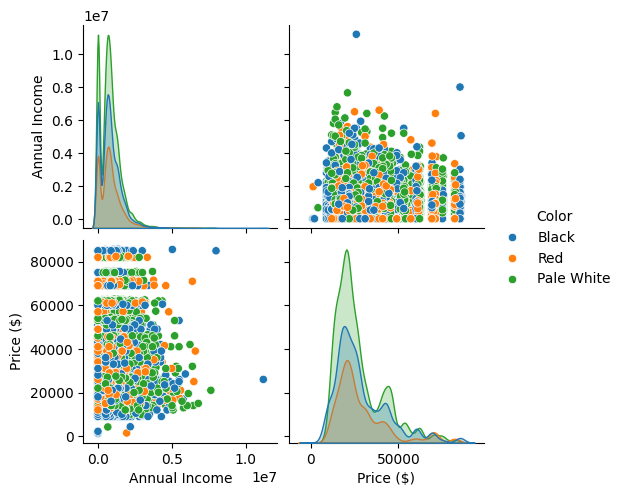

<Figure size 800x300 with 0 Axes>

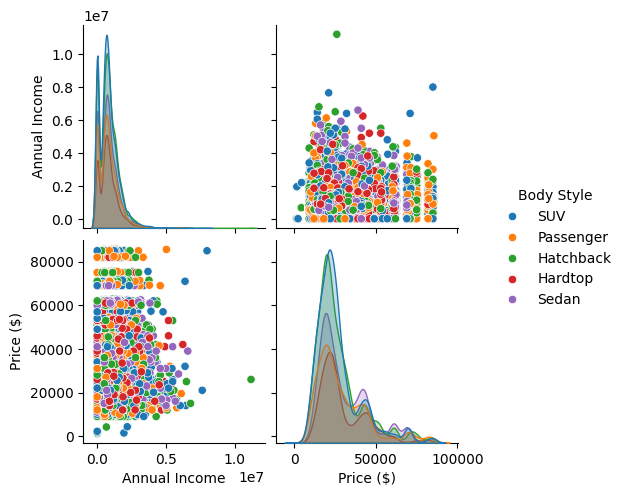

<Figure size 800x300 with 0 Axes>

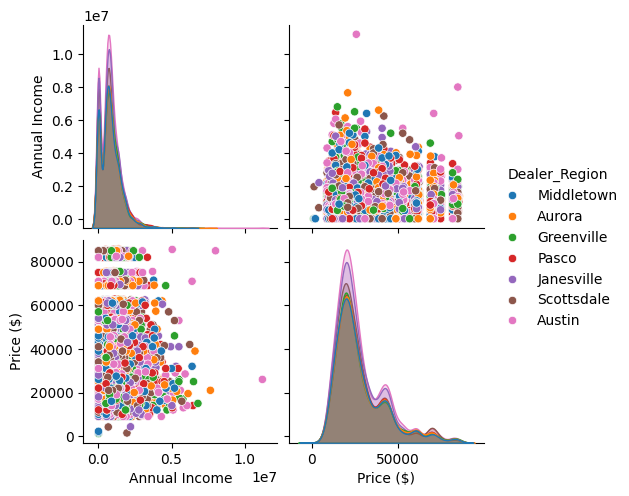

In [40]:
for i in categorical_cols:
  plt.figure(figsize=(8,3))
  sns.pairplot(df[['Annual Income', 'Price ($)',i]], hue=i)
  plt.show()

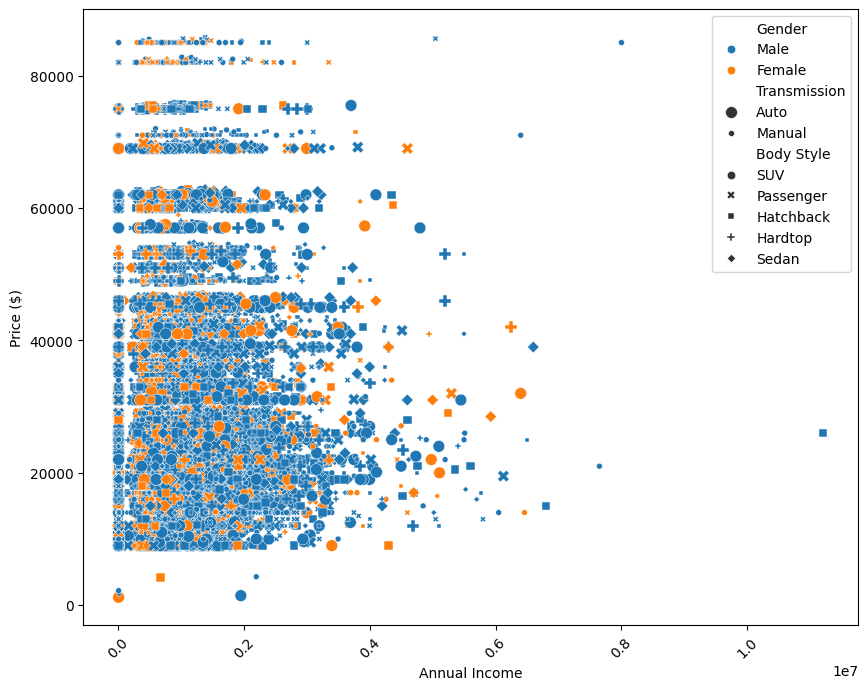

In [41]:
plt.figure(figsize=(10,8))
sns.scatterplot(data=df,x='Annual Income' ,y='Price ($)' ,hue='Gender' ,style='Body Style' ,size='Transmission')
plt.xticks(rotation=45)
plt.show()